<a href="https://colab.research.google.com/github/leishapm/fakereviewsanalyser/blob/main/FakeReviewsDetection_Deliverable3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake Reviews Analyzer

## Cross-Domain Detection of Deceptive Online Reviews

**Team Members:**
- Harshini Mahalingam  
- Menezes Leisha Pritika  
- Nandit Ramesh  

---

Online reviews are a cornerstone of consumer trust, but a significant proportion are fabricated or incentivised. Studies estimate **up to 30% of reviews** on platforms like Amazon, TripAdvisor, and the Google Play Store may be inauthentic. With the rise of LLMs capable of generating fluent, human-like text, automated detection has become both more critical and more challenging.

This notebook builds a **complete fake review detection pipeline** that goes beyond single-domain benchmarking. It deliberately trains on one type of platform and evaluates on another, mirroring real-world deployment conditions where a model encounters review types it has never seen before.

---

### Project Architecture

| Stage | Section | Description |
|---|---|---|
| **Ask** | 1 | Define the research question and hypothesis |
| **Prepare** | 2–3 | Setup, data loading, and source identification |
| **Profile** | 4 | Assess structure, quality, and label availability |
| **Enrich** | 5–6 | Extract linguistic features from raw text |
| **Clean** | 7 | Standardise text for modelling |
| **Structure** | 8 | Unify schema across all four datasets |
| **Analyse** | 9 | Descriptive, diagnostic, and predictive analytics |
| **Model** | 10 | Hybrid Bidirectional LSTM + engineered features |
| **Predict** | 11 | Cross-domain inference on unlabelled datasets |

---

### Dataset Roles

| Dataset | Source | Domain | Role |
|---|---|---|---|
| **DS1** | Fake Reviews Dataset (Kaggle) | Product | Supervised training — 20k genuine + 20k AI-generated |
| **DS2** | Deceptive Opinion Spam Corpus | Hotel | Supervised training — 4-quadrant human deception study |
| **DS3** | Google Play Store Reviews | App | **Cross-domain evaluation** — unlabelled |
| **DS4** | TripAdvisor Hotel Reviews | Hotel | **Cross-domain evaluation** — unlabelled |

> **Why this matters:** Most fake review classifiers are evaluated on the *same domain* they were trained on. This inflates performance estimates. By separating training and evaluation across domains, this project tests whether **linguistic deception signals truly transfer**.

---
#  1 · Hypothesis Testing (Ask)

## Research Question
> **How do AI-generated and human-written fake reviews differ linguistically, and what does this reveal about the limits of cross-domain fake review detection?**

## Hypotheses

| # | Hypothesis | Operationalisation | Testable? |
|---|---|---|---|
| H₁ | AI-generated reviews exhibit higher word repetition (self-repetition ratio) than genuine reviews | Mann-Whitney U on self_repetition_ratio: DS1 CG vs OR |  DS1 labels |
| H₂ | Human-deceptive reviews (DS2) are harder to distinguish by surface features than AI fakes (DS1) | Mean |r| across features is lower for DS2 than DS1 |  Both labelled |
| H₃ | The model trained on DS1 alone will predict a higher *fake confidence* on DS4 (hotel) than DS3 (app), reflecting domain proximity | Mean max-softmax score on DS4 > DS3 (no ground truth needed) |  Proxy via confidence |
| H₄ | Punctuation style and narrative perspective are statistically associated with review label | Chi-square test on both categorical features |  DS1+DS2 labels |

> **Note on H₃:** DS3 and DS4 are unlabelled so F1 is unmeasurable. H₃ is instead operationalised as a *confidence proxy*: if domain proximity matters, the model should assign higher mean fake-class confidence to DS4 (same domain as DS2 training data) than DS3 (out-of-domain app reviews). This is tested in §12.

## Problem Definition

The pipeline separates training from evaluation by domain **in two distinct ways**:

1. **Within-domain cross-validation** — DS1 trained, DS1 tested (§11 standard evaluation)
2. **True cross-domain generalisation** — DS1 only → DS2 evaluation, and DS2 only → DS1 evaluation (§11.3 cross-domain holdout)
3. **Unlabelled inference** — DS3 and DS4 receive predictions only (§12)

This is a **linguistic transferability** study: not just "can we detect fake reviews?" but "do fake review patterns hold across platforms?"


---
#  2 · Setup

All required libraries are installed and imported here. Key dependencies:
- **`pandas` / `numpy`** — data manipulation
- **`matplotlib` / `seaborn`** — visualisation
- **`nltk`** — tokenisation, stopwords, POS tagging, VADER sentiment, lemmatisation
- **`scikit-learn`** — feature scaling, TF-IDF, linear models, evaluation metrics
- **`tensorflow`** — Bidirectional LSTM model
- **`scipy` / `statsmodels`** — statistical hypothesis tests


In [ ]:

!pip install nltk scikit-learn tensorflow --quiet

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import json
import re
import string
from pprint import pprint
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords, wordnet as wn
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('vader_lexicon',quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("✓ All libraries imported")

✓ All libraries imported


---
# 3 · Data Source Identification & Exploration (Prepare)

## Dataset Selection Rationale

Four datasets were chosen with deliberate diversity:

1. **Relevance** — all contain review text with potential linguistic deception signals
2. **Label availability** — DS1 and DS2 carry ground-truth labels for supervised training; DS3 and DS4 are unlabelled (real-world)
3. **Domain diversity** — product, hotel, and app contexts enable cross-domain generalisation testing
4. **Provenance** — all are publicly documented Kaggle datasets with clear column definitions
5. **Scale & balance** — DS1 has a balanced 50/50 fake/genuine split across 40,000 reviews; DS2 is balanced across four quadrants (deceptive/truthful × positive/negative)
6. **Realistic evaluation** — DS3 and DS4 are unlabelled, mirroring actual production conditions

## Datasets

| ID | Name | URL |
|---|---|---|
| DS1 | Fake Reviews Dataset | https://www.kaggle.com/datasets/mexwell/fake-reviews-dataset |
| DS2 | Deceptive Opinion Spam Corpus | https://www.kaggle.com/datasets/rtatman/deceptive-opinion-spam-corpus |
| DS3 | Google Play Store Reviews | https://www.kaggle.com/datasets/crawlfeeds/google-play-store-reviews |
| DS4 | TripAdvisor Hotel Reviews | https://www.kaggle.com/datasets/thedevastator/tripadvisor-hotel-reviews |


In [ ]:

BASE_DIRS = [
    Path("/content/drive/MyDrive/SC3021Notebook/SC3021Notebook"),
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / "Downloads",
]

def locate_file(filename):
    for base in BASE_DIRS:
        candidate = base / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in any known folder")

PATHS = {
    "DS1": locate_file("fake_reviews_dataset.csv"),
    "DS2": locate_file("deceptive-opinion.csv"),
    "DS3": locate_file("google_play_store_reviews.csv"),
    "DS4": locate_file("tripadvisor_hotel_reviews.csv"),
}

META = {
    "DS1": {
        "description":  "Fake Reviews Dataset (Kaggle)",
        "unit":         "One row = one product review",
        "label_status": "Labelled",
        "label_col":    "label",
        "text_col":     "text_",
        "role":         "Primary training dataset — 20k genuine (OR) + 20k computer-generated (CG) reviews",
    },
    "DS2": {
        "description":  "Deceptive Opinion Spam Corpus (Kaggle)",
        "unit":         "One row = one hotel review",
        "label_status": "Labelled",
        "label_col":    "deceptive",
        "text_col":     "text",
        "role":         "Secondary training dataset — truthful/deceptive × positive/negative hotel reviews",
    },
    "DS3": {
        "description":  "Google Play Store Reviews (Kaggle)",
        "unit":         "One row = one app review",
        "label_status": "Unlabelled",
        "label_col":    None,
        "text_col":     "Content",
        "role":         "Real-world evaluation dataset — app reviews without fake/genuine labels",
    },
    "DS4": {
        "description":  "TripAdvisor Hotel Reviews (Kaggle)",
        "unit":         "One row = one hotel review",
        "label_status": "Unlabelled",
        "label_col":    None,
        "text_col":     "Review",
        "role":         "Real-world evaluation dataset — hotel reviews without fake/genuine labels",
    },
}

print("Resolved dataset paths:")
for name, path in PATHS.items():
    print(f"  {name}: {path}")

Resolved dataset paths:
  DS1: /content/drive/MyDrive/SC3021Notebook/SC3021Notebook/fake_reviews_dataset.csv
  DS2: /content/drive/MyDrive/SC3021Notebook/SC3021Notebook/deceptive-opinion.csv
  DS3: /content/drive/MyDrive/SC3021Notebook/SC3021Notebook/google_play_store_reviews.csv
  DS4: /content/drive/MyDrive/SC3021Notebook/SC3021Notebook/tripadvisor_hotel_reviews.csv


### Dataset Previews

The first three rows of each dataset are printed below. This gives a quick sanity check that paths resolve correctly and confirms which column holds review text and which holds the label.


In [ ]:

for name, path in PATHS.items():
    print("\n" + "="*60)
    print(f"  {name} — {META[name]['description']}")
    print("="*60)
    df_preview = pd.read_csv(path)
    for i in range(min(3, len(df_preview))):
        pprint(df_preview.iloc[i].to_dict())
        print("-"*40)


  DS1 — Fake Reviews Dataset (Kaggle)
{'category': 'Home_and_Kitchen_5',
 'label': 'CG',
 'rating': 5,
 'text_': 'Love this!  Well made, sturdy, and very comfortable.  I love '
          'it!Very pretty'}
----------------------------------------
{'category': 'Home_and_Kitchen_5',
 'label': 'CG',
 'rating': 5,
 'text_': "love it, a great upgrade from the original.  I've had mine for a "
          'couple of years'}
----------------------------------------
{'category': 'Home_and_Kitchen_5',
 'label': 'CG',
 'rating': 5,
 'text_': 'This pillow saved my back. I love the look and feel of this pillow.'}
----------------------------------------

  DS2 — Deceptive Opinion Spam Corpus (Kaggle)
{'deceptive': 'truthful',
 'hotel': 'conrad',
 'polarity': 'positive',
 'source': 'TripAdvisor',
 'text': 'We stayed for a one night getaway with family on a thursday. Triple '
         'AAA rate of 173 was a steal. 7th floor room complete with 44in '
         'plasma TV bose stereo, voss and evian water

---
#  4 · Data Profiling (Prepare)

Before any processing, each dataset is systematically profiled to assess its:
- **Shape** — row and column counts
- **Data types** — numeric, categorical, or text
- **Missing values** — proportion of nulls per column
- **Duplicates** — repeated review texts that could bias training
- **Label distribution** — class balance for labelled datasets
- **Text length statistics** — character count distribution as a quality signal

> **Why profile before anything else?**  
> Profiling surfaces data quality issues *before* enriching or cleaning. If a dataset is severely imbalanced or has many duplicates, that shapes every downstream decision.


In [ ]:
def profile_dataset(name, path, meta):
    """Returns a dict of profiling statistics for one CSV dataset."""
    df = pd.read_csv(path)
    text_col  = meta["text_col"]
    label_col = meta["label_col"]

    n_rows, n_cols = df.shape
    n_duplicates   = df.duplicated().sum()

    df["_text_len"] = df[text_col].astype(str).str.len()
    text_stats = df["_text_len"].describe().rename("chars").round(1)

    missing     = df.isnull().sum()
    missing_pct = (missing / n_rows * 100).round(2)

    label_dist = df[label_col].value_counts() if label_col else None

    return {
        "name":         name,
        "meta":         meta,
        "df":           df,
        "n_rows":       n_rows,
        "n_cols":       n_cols,
        "dtypes":       df.dtypes,
        "missing":      missing,
        "missing_pct":  missing_pct,
        "n_duplicates": n_duplicates,
        "text_stats":   text_stats,
        "label_dist":   label_dist,
    }

profiles = {name: profile_dataset(name, path, META[name]) for name, path in PATHS.items()}
print("✓ All datasets loaded and profiled.")

✓ All datasets loaded and profiled.


In [ ]:
# Summary table
summary_rows = []
for name, p in profiles.items():
    summary_rows.append({
        "Dataset":      name,
        "Description":  p["meta"]["description"],
        "Rows":         f"{p['n_rows']:,}",
        "Columns":      p["n_cols"],
        "Label status": p["meta"]["label_status"],
        "Duplicates":   p["n_duplicates"],
        "Any missing?": "Yes" if p["missing"].any() else "No",
        "Unit":         p["meta"]["unit"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("Dataset")
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
display(summary_df)

DATASET SUMMARY


,Description,Rows,Columns,Label status,Duplicates,Any missing?,Unit
Dataset,,,,,,,
DS1,Fake Reviews Dataset (Kaggle),"40,432",4,Labelled,13,No,One row = one product review
DS2,Deceptive Opinion Spam Corpus (Kaggle),"1,600",5,Labelled,4,No,One row = one hotel review
DS3,Google Play Store Reviews (Kaggle),"1,080",13,Unlabelled,0,Yes,One row = one app review
DS4,TripAdvisor Hotel Reviews (Kaggle),"20,491",3,Unlabelled,0,No,One row = one hotel review


In [ ]:

for name, p in profiles.items():
    sep = "=" * 70
    print(f"\n{sep}")
    print(f"  {name}  —  {p['meta']['description']}")
    print(sep)
    print(f"  Role          : {p['meta']['role']}")
    print(f"  Unit          : {p['meta']['unit']}")
    print(f"  Label status  : {p['meta']['label_status']}")
    print(f"\n  Shape         : {p['n_rows']:,} rows  ×  {p['n_cols']} columns")
    print(f"  Duplicates    : {p['n_duplicates']}")

    print("\n  --- Column data types ---")
    for col, dtype in p["dtypes"].items():
        pct  = p["missing_pct"][col]
        miss = f"  [{pct}% missing]" if pct > 0 else ""
        print(f"    {col:<35} {str(dtype):<12}{miss}")

    print("\n  --- Text length statistics (characters) ---")
    for stat, val in p["text_stats"].items():
        print(f"    {stat:<10} {val}")

    if p["label_dist"] is not None:
        print("\n  --- Label distribution ---")
        total = p["label_dist"].sum()
        for label, count in p["label_dist"].items():
            pct = count / total * 100
            print(f"    {str(label):<20} {count:>6,}  ({pct:.1f}%)")
    print()


  DS1  —  Fake Reviews Dataset (Kaggle)
  Role          : Primary training dataset — 20k genuine (OR) + 20k computer-generated (CG) reviews
  Unit          : One row = one product review
  Label status  : Labelled

  Shape         : 40,432 rows  ×  4 columns
  Duplicates    : 13

  --- Column data types ---
    category                            object      
    rating                              int64       
    label                               object      
    text_                               object      
    _text_len                           int64       

  --- Text length statistics (characters) ---
    count      40432.0
    mean       351.3
    std        369.8
    min        5.0
    25%        107.0
    50%        198.0
    75%        439.0
    max        2827.0

  --- Label distribution ---
    CG                   20,216  (50.0%)
    OR                   20,216  (50.0%)


  DS2  —  Deceptive Opinion Spam Corpus (Kaggle)
  Role          : Secondary training dataset —

### 4.1 Missing Values

Missing values are visualised as a heatmap. A red cell means that column has missing data. This immediately shows which features can be used as-is and which need imputation.


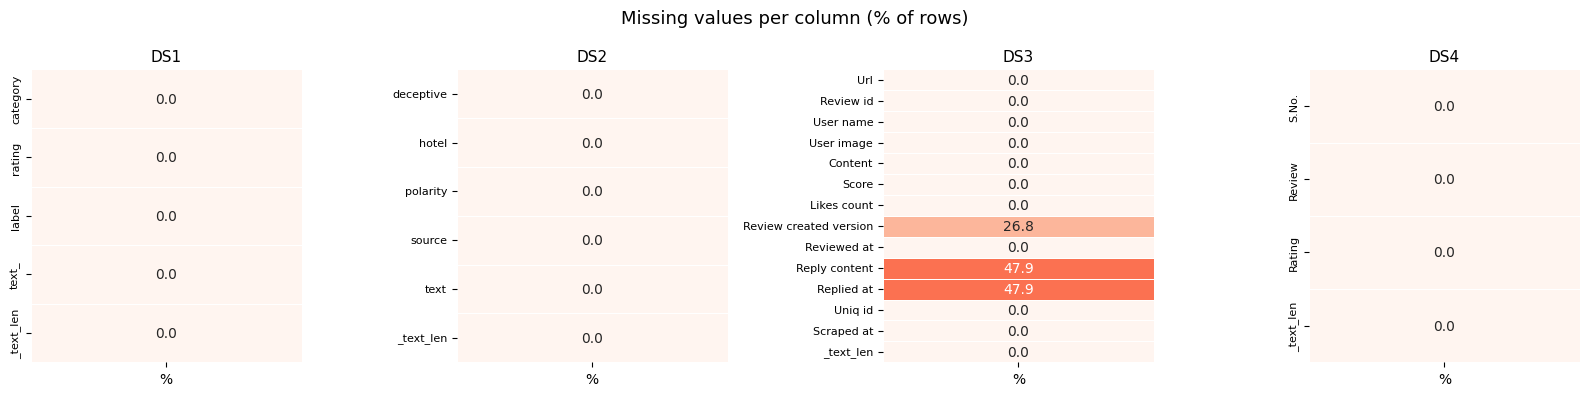

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Missing values per column (% of rows)", fontsize=13)

for ax, (name, p) in zip(axes, profiles.items()):
    pct  = p["missing_pct"].values.reshape(-1, 1)
    cols = p["missing_pct"].index.tolist()
    sns.heatmap(
        pct, ax=ax,
        annot=True, fmt=".1f",
        cmap="Reds", vmin=0, vmax=100,
        cbar=False, linewidths=0.5,
        yticklabels=cols, xticklabels=["%"],
    )
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

**Observation:** DS3 has missing values in `review_created_version`, `reply_content`, and `replied_at`. These are metadata columns rather than review text, so they do not affect text modelling. All other datasets are complete for the columns used in this pipeline.


### 4.2 Review Length Analysis

Review length (in characters) is plotted by label for the labelled datasets, and as histograms for all four. Length is the simplest possible feature,checking whether it separates fake from genuine tells us how much "low-hanging fruit" the data contains.


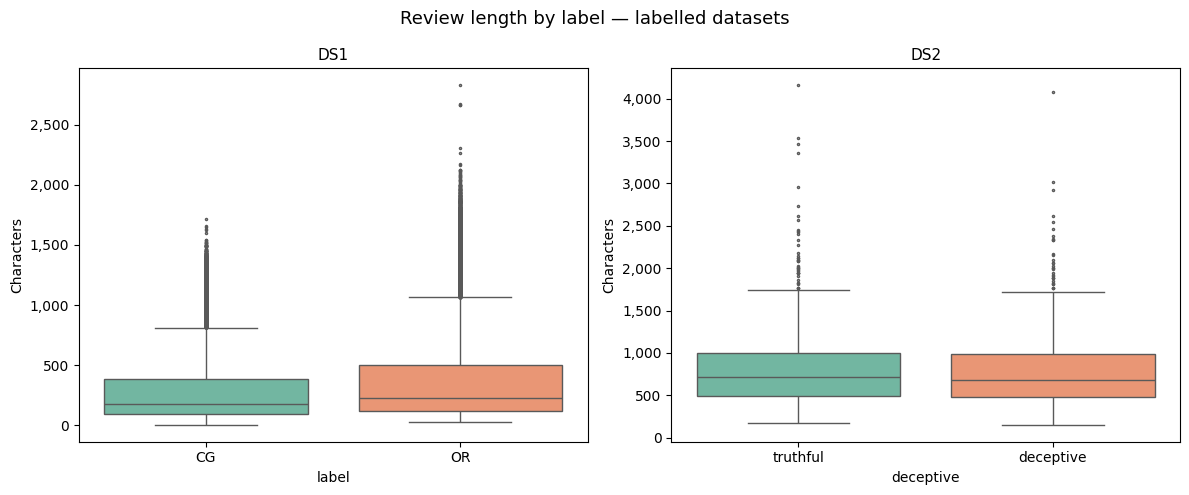

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Review length by label — labelled datasets", fontsize=13)

for ax, name in zip(axes, ["DS1", "DS2"]):
    p         = profiles[name]
    df        = p["df"]
    label_col = p["meta"]["label_col"]
    sns.boxplot(data=df, x=label_col, y="_text_len", ax=ax,
                hue=label_col, legend=False,
                palette="Set2", flierprops={"marker": ".", "markersize": 3})
    ax.set_title(f"{name}", fontsize=11)
    ax.set_xlabel(label_col)
    ax.set_ylabel("Characters")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

**In Review length does not generalise across domains.**  
In DS1, AI-generated fakes tend to be *longer* than genuine reviews, likely because LLMs over-explain. However, in DS2, deceptive reviews closely match the length of truthful ones. Humans writing fake hotel reviews are aware of length as a tell. Length is therefore **not a reliable cross-domain discriminator**.


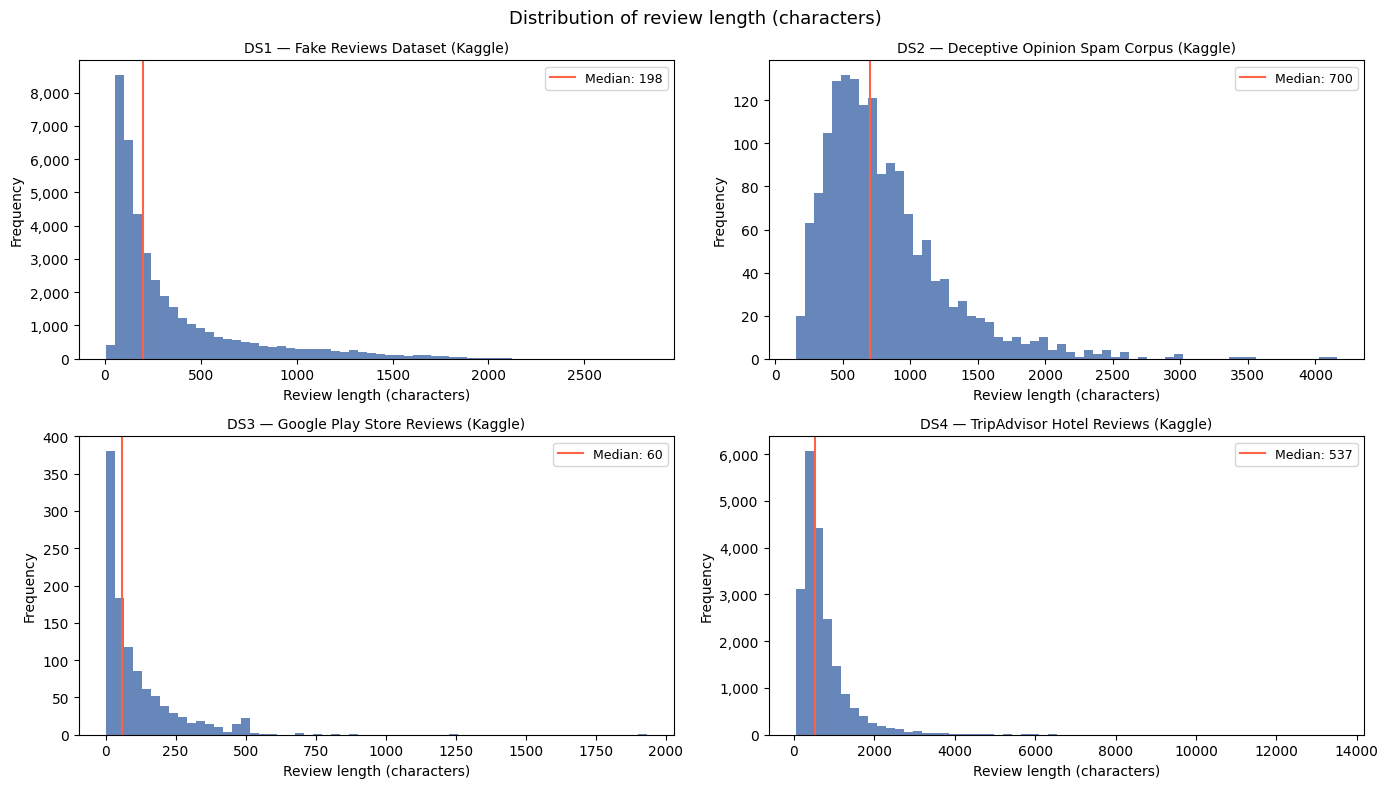

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Distribution of review length (characters)", fontsize=13)

for ax, (name, p) in zip(axes.flat, profiles.items()):
    df = p["df"]
    ax.hist(df["_text_len"], bins=60, color="#4C72B0", edgecolor="none", alpha=0.85)
    ax.axvline(df["_text_len"].median(), color="tomato", linewidth=1.5,
               label=f"Median: {df['_text_len'].median():.0f}")
    ax.set_title(f"{name} — {p['meta']['description']}", fontsize=10)
    ax.set_xlabel("Review length (characters)")
    ax.set_ylabel("Frequency")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Insight: The four datasets occupy completely different length regimes.**  
DS3 (app reviews) has a median of ~60 characters. DS1 (product reviews) is ~198. DS2 (hotel spam corpus) is ~700. DS4 (TripAdvisor) is ~537, making it the closest match to DS2 in length distribution. This domain shift is a key challenge for cross-domain generalisation.


### 4.3 Duplicate Review Analysis

Duplicate texts are checked across all datasets. Duplicates in training data artificially inflate model confidence on repeated examples and should be removed before cleaning.


Duplicate Data Analysis Summary:


,Dataset,Total Rows,Duplicate Rows,Duplicate %
2,DS3,1080,42,3.888889
1,DS2,1600,4,0.250000
0,DS1,40432,21,0.051939
3,DS4,20491,0,0.000000


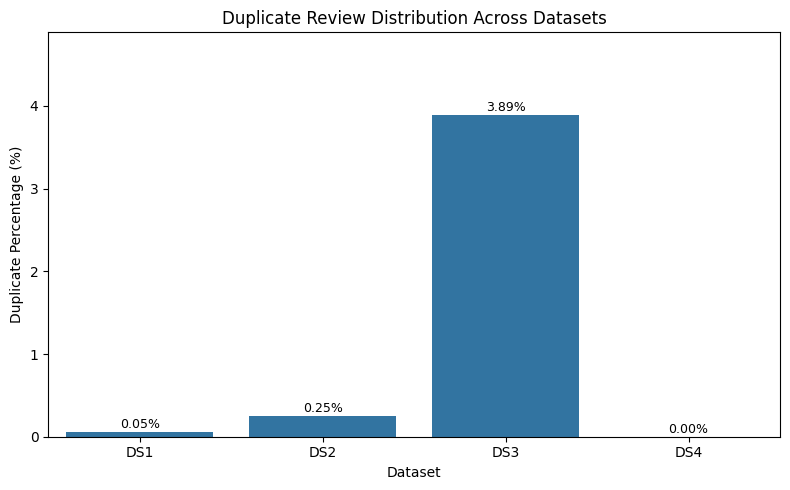

In [ ]:
results = []
for name, p in profiles.items():
    data     = p["df"]
    text_col = p["meta"]["text_col"]
    total    = len(data)
    dup_rows = data.duplicated(subset=[text_col]).sum() if text_col in data.columns                else data.duplicated().sum()
    results.append([name, total, dup_rows, dup_rows / total * 100])

dup_df = pd.DataFrame(results, columns=["Dataset", "Total Rows", "Duplicate Rows", "Duplicate %"])

print("Duplicate Data Analysis Summary:")
display(dup_df.sort_values("Duplicate %", ascending=False))

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=dup_df, x="Dataset", y="Duplicate %")
for i, val in enumerate(dup_df["Duplicate %"]):
    plt.text(i, val + 0.05, f"{val:.2f}%", ha='center', fontsize=9)
plt.title("Duplicate Review Distribution Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Duplicate Percentage (%)")
plt.ylim(0, dup_df["Duplicate %"].max() + 1)
plt.tight_layout()
plt.show()

**Observation:** DS3 has the highest duplication rate at 3.89%, consistent with copy-paste app review spam. DS1 and DS2 are very low (0.05% and 0.25% respectively). DS4 has no duplicates. Duplicates are removed in §7 (Cleaning).


---
#  5 · Data Enriching (Prepare)

>  **Enriching must happen BEFORE cleaning.**  
> Many linguistic signals — capitalisation ratios, exclamation counts, punctuation variety — are destroyed by the cleaning pipeline. They must be extracted from the *raw* text.

## Features Engineered

| Feature | Signal direction | What it captures |
|---|---|---|
| `char_count` / `word_count` | — | Basic length statistics |
| `avg_word_len` | ↑ OR | Longer words → more specific vocabulary |
| `exclamation_count` | ↑ CG | Promotional over-enthusiasm |
| `question_count` | — | Interrogative style |
| `capital_ratio` | ↑ CG | ALL-CAPS usage as emphasis |
| `rating_extremity` | ↑ fake | Distance from neutral rating of 3 |
| `self_repetition_ratio` | ↑ CG | **Strongest feature** — proportion of duplicate words in a review |
| `first_person_I_count` | ↑ CG | I-usage without product context |
| `generic_praise_count` | ↑ CG | Surface superlatives ("amazing", "perfect", "best") |
| `specific_feature_count` | ↑ OR | Concrete product references ("battery", "stitching", "texture") |
| `hollow_i_ratio` | ↑ CG | I-count ÷ specific features — a CG fingerprint |
| `is_short_review` | ↑ CG | Reviews under 20 words |




In [ ]:
def enrich_dataset(name, p):
    df       = p["df"].copy()
    text_col = p["meta"]["text_col"]


    df.insert(0, "review_id", [f"{name}_{i+1}" for i in range(len(df))])


    df["char_count"]  = df[text_col].astype(str).str.len()
    df["word_count"]  = df[text_col].astype(str).str.split().str.len()
    df["avg_word_len"] = df["char_count"] / df["word_count"].replace(0, 1)

    df["exclamation_count"] = df[text_col].astype(str).str.count(r"\!")
    df["question_count"]    = df[text_col].astype(str).str.count(r"\?")
    df["capital_ratio"]     = (
        df[text_col].astype(str)
        .apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    )


    rating_col = {"DS1": "rating", "DS2": None, "DS3": "Score", "DS4": "Rating"}.get(name)
    if rating_col and rating_col in df.columns:
        df["rating_extremity"] = abs(df[rating_col] - 3)

    if name == "DS1":
        df["is_fake"] = (df["label"] == "CG").astype(int)


    if name == "DS2":
        df["is_fake"]     = (df["deceptive"] == "deceptive").astype(int)
        df["is_positive"] = (df["polarity"]  == "positive").astype(int)


    if name == "DS3" and "Reply content" in df.columns:
        df["has_reply"] = df["Reply content"].notna().astype(int)


    def _self_rep(text):
        words = re.findall(r'\b\w+\b', str(text).lower())
        return (len(words) - len(set(words))) / max(len(words), 1)

    df["self_repetition_ratio"] = df[text_col].astype(str).apply(_self_rep)

    df["first_person_I_count"] = df[text_col].astype(str).apply(
        lambda x: len(re.findall(r'\bI\b', x))
    )

    df["is_short_review"] = (df["word_count"] < 20).astype(int)


    _PRAISE = {"love", "great", "perfect", "amazing", "awesome", "excellent",
               "wonderful", "fantastic", "best", "good"}
    _NEGATORS = {"not", "never", "hardly", "barely", "no", "nothing"}

    def _praise_count(text):
        words = text.lower().split()
        count = 0
        for i, w in enumerate(words):
            w_clean = w.strip(".,!?;:'\"")
            if w_clean in _PRAISE:
                # Check 2-word negation window
                window = {words[j].strip(".,!?;:'\"") for j in range(max(0, i-2), i)}
                if not window & _NEGATORS:
                    count += 1
        return count

    df["generic_praise_count"] = df[text_col].astype(str).apply(_praise_count)


    _SPECIFIC = {

        "color", "colour", "size", "weight", "material", "fit", "smell",
        "texture", "taste", "sound", "battery", "screen", "button",
        "zipper", "seam", "stitching",

        "room", "bed", "view", "staff", "location", "bathroom", "shower",
        "wifi", "pool", "lobby", "breakfast", "parking", "elevator", "floor",
        "window", "pillow", "towel", "check-in", "checkout", "noise",

        "crash", "update", "interface", "notification", "login", "bug",
        "feature", "button", "load", "sync", "lag", "freeze", "version",
        "subscription", "purchase", "refund", "permission"
    }
    df["specific_feature_count"] = df[text_col].astype(str).apply(
        lambda x: sum(1 for w in x.lower().split() if w.strip(".,!?") in _SPECIFIC)
    )

    df["hollow_i_ratio"] = df["first_person_I_count"] / (df["specific_feature_count"] + 1)

    return df

enriched = {}
for name, p in profiles.items():
    enriched[name] = enrich_dataset(name, p)
    print(f"{name}: {enriched[name].shape} — enriched")

print("\n All datasets enriched.")

DS1: (40432, 20) — enriched
DS2: (1600, 21) — enriched
DS3: (1080, 29) — enriched
DS4: (20491, 18) — enriched

 All datasets enriched.


### 5.1 EDA-Derived Feature Summary

The table below summarises each engineered feature and its expected direction relative to the fake label.

| Feature | Signal direction | Description |
|---|---|---|
| `self_repetition_ratio` | ↑ CG | Proportion of duplicate words within a review |
| `first_person_I_count` | ↑ CG | Raw count of "I" — hollow usage without product context |
| `is_short_review` | ↑ CG | Flag for reviews under 20 words |
| `generic_praise_count` | ↑ CG | Count of surface-level superlatives |
| `specific_feature_count` | ↑ OR | Count of concrete product/sensory references |
| `hollow_i_ratio` | ↑ CG | I-count divided by specific features — CG fingerprint |

The plots below verify these expectations on DS1 (labelled). Red = Fake (CG), Blue = Genuine (OR). We expect visible separation for the ↑ CG features.


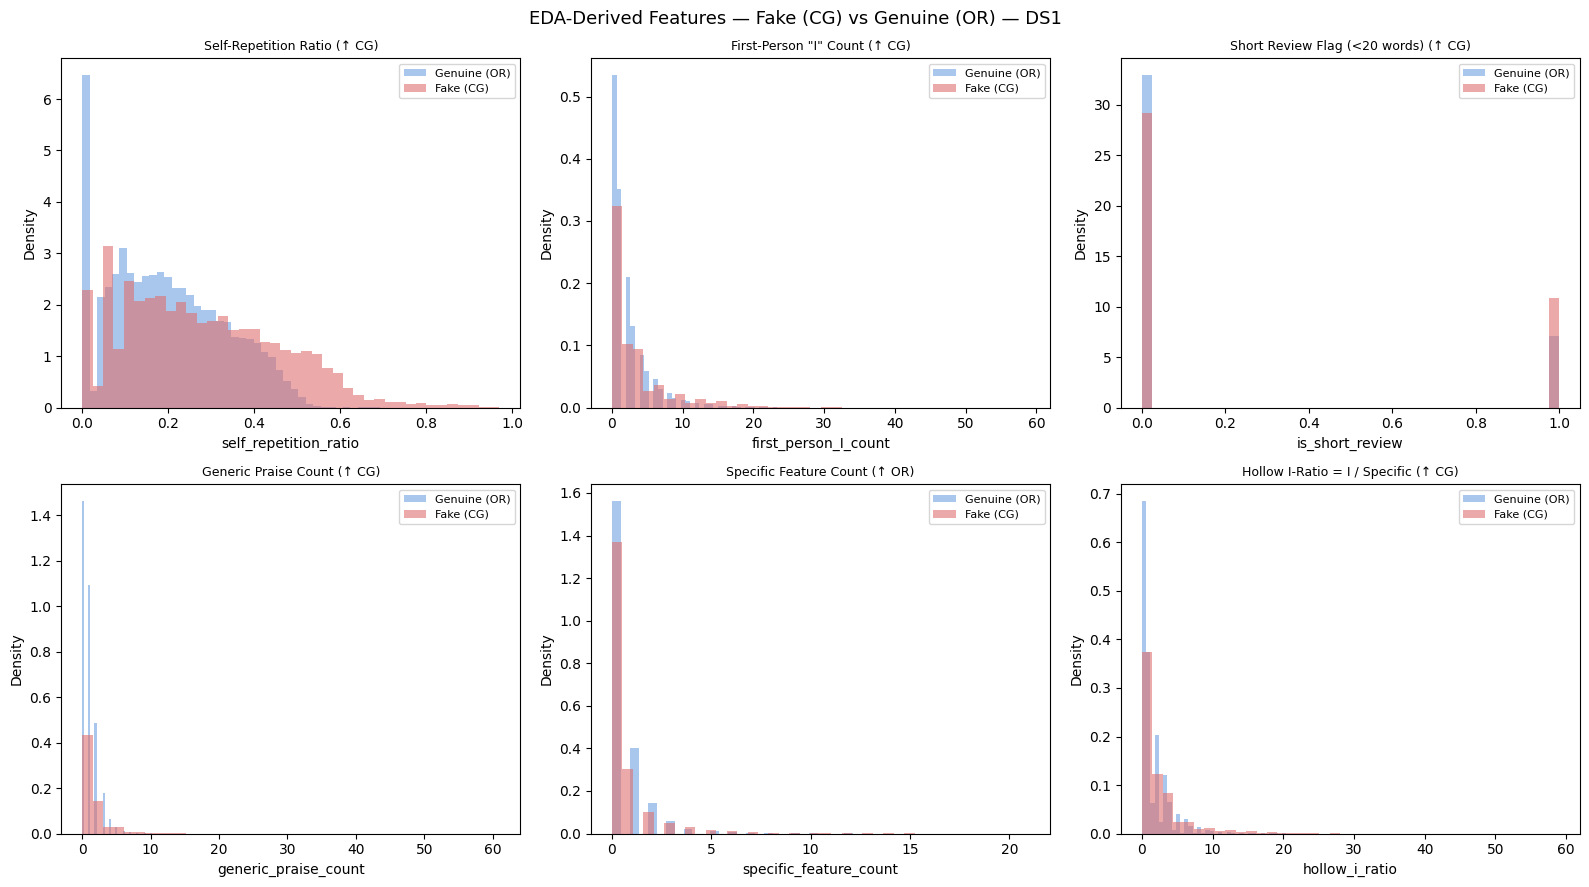


Correlation of EDA-derived features with is_fake (DS1):
  self_repetition_ratio          r = +0.2479
  first_person_I_count           r = +0.1530
  is_short_review                r = +0.1135
  generic_praise_count           r = +0.1535
  specific_feature_count         r = +0.0266
  hollow_i_ratio                 r = +0.1445


In [ ]:

eda_features = [
    ('self_repetition_ratio',  'Self-Repetition Ratio (↑ CG)'),
    ('first_person_I_count',   'First-Person "I" Count (↑ CG)'),
    ('is_short_review',        'Short Review Flag (<20 words) (↑ CG)'),
    ('generic_praise_count',   'Generic Praise Count (↑ CG)'),
    ('specific_feature_count', 'Specific Feature Count (↑ OR)'),
    ('hollow_i_ratio',         'Hollow I-Ratio = I / Specific (↑ CG)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA-Derived Features — Fake (CG) vs Genuine (OR) — DS1', fontsize=13)

df_ds1 = enriched['DS1'].dropna(subset=['is_fake'])

for ax, (feat, label) in zip(axes.flat, eda_features):
    if feat not in df_ds1.columns:
        ax.set_title(f'{label}\n(not computed)')
        ax.axis('off')
        continue
    for is_fake, grp in df_ds1.groupby('is_fake'):
        vals = grp[feat].replace([float('inf'), float('-inf')], float('nan')).dropna()
        ax.hist(vals, bins=40, alpha=0.6, density=True,
                label='Fake (CG)' if is_fake == 1 else 'Genuine (OR)',
                color='#E07070' if is_fake == 1 else '#70A0E0')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nCorrelation of EDA-derived features with is_fake (DS1):')
for feat, _ in eda_features:
    if feat in df_ds1.columns:
        r = df_ds1[feat].corr(df_ds1['is_fake'])
        print(f'  {feat:<30} r = {r:+.4f}')

---
#  6 · Advanced Linguistic Feature Engineering

Basic surface features (word count, exclamation marks) capture only the most obvious signals. This section adds six NLP-motivated features that target subtler patterns associated with AI-generated and human-deceptive text.

| Feature | What it captures | Expected direction |
|---|---|---|
| `ttr` (Type-Token Ratio) | Vocabulary diversity — low TTR means repetitive vocabulary | ↓ CG |
| `repetition_score` | Bigram repetition — how often the same two-word sequence recurs | ↑ CG |
| `specificity_score` | Numbers and proper nouns — concrete detail that real reviewers include | ↑ OR |
| `buzzword_density` | Generic marketing vocabulary ("revolutionary", "seamless", "best-in-class") | ↑ CG |
| `sent_len_variance` | Variance in sentence lengths — LLMs tend toward uniform sentence structure | ↓ CG |
| `consecutive_sent_sim` | Cosine similarity between adjacent sentences — AI often paraphrases itself | ↑ CG |

> **Performance note:** `consecutive_sent_sim` fits a TF-IDF vectorizer per review and is slow. It runs on a sample of 2,000 reviews for speed. Adjust `SIM_SAMPLE` as needed.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def type_token_ratio(text):
    words = str(text).lower().split()
    return len(set(words)) / len(words) if words else 0

def repetition_score(text):
    words = str(text).lower().split()
    if len(words) < 2:
        return 0
    bigrams = [f"{words[i]}_{words[i+1]}" for i in range(len(words)-1)]
    counts  = Counter(bigrams)
    repeated = sum(v for v in counts.values() if v > 1)
    return repeated / len(bigrams)

def specificity_score(text):
    words = str(text).split()
    if not words:
        return 0
    numbers = sum(1 for w in words if re.search(r'\d', w))
    proper  = sum(1 for i, w in enumerate(words[1:], 1) if w and w[0].isupper())
    return (numbers + proper) / len(words)

BUZZWORDS = {
    'amazing','incredible','fantastic','outstanding','exceptional',
    'seamless','robust','innovative','cutting-edge','state-of-the-art',
    'world-class','best-in-class','game-changing','revolutionary',
    'transformative','unparalleled','perfect','absolutely',
    'wonderful','flawless','superb'
}

def buzzword_density(text):
    words = str(text).lower().split()
    return sum(1 for w in words if w.strip('.,!?') in BUZZWORDS) / len(words) if words else 0

def avg_sentence_similarity_variance(text):
    sentences = [s.strip() for s in re.split(r'[.!?]+', str(text)) if s.strip()]
    if len(sentences) < 2:
        return 0
    return float(np.var([len(s.split()) for s in sentences]))

def consecutive_sentence_similarity(text):
    """Cosine similarity between consecutive sentences.
    FIX: Previously sampled to 2000 rows, leaving ~85% of training data as NaN
    (then median-imputed), which contributes noise not signal.
    Now computed on ALL rows using a lightweight numpy dot-product approach
    (no per-review TfidfVectorizer fitting — shared vocabulary across sentences).
    """
    sentences = [s.strip() for s in re.split(r'[.!?]+', str(text)) if len(s.strip()) > 5]
    if len(sentences) < 2:
        return 0.0

    vocab = {}
    for s in sentences:
        for w in s.lower().split():
            if w not in vocab:
                vocab[w] = len(vocab)
    n = len(vocab)
    if n == 0:
        return 0.0
    vecs = np.zeros((len(sentences), n), dtype=np.float32)
    for i, s in enumerate(sentences):
        for w in s.lower().split():
            vecs[i, vocab[w]] += 1
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    vecs = vecs / norms
    sims = []
    for i in range(len(vecs) - 1):
        sims.append(float(np.dot(vecs[i], vecs[i+1])))
    return float(np.mean(sims)) if sims else 0.0

def add_advanced_features(df, text_col):
    df    = df.copy()
    texts = df[text_col].astype(str)

    print(f"  TTR...")
    df['ttr']               = texts.apply(type_token_ratio)
    print(f"  Bigram repetition...")
    df['repetition_score']  = texts.apply(repetition_score)
    print(f"  Specificity...")
    df['specificity_score'] = texts.apply(specificity_score)
    print(f"  Buzzword density...")
    df['buzzword_density']  = texts.apply(buzzword_density)
    print(f"  Sentence length variance...")
    df['sent_len_variance'] = texts.apply(avg_sentence_similarity_variance)

    print(f"  Consecutive sentence similarity (all rows)...")
    df['consecutive_sent_sim'] = texts.apply(consecutive_sentence_similarity)

    return df

for name, df in enriched.items():
    print(f"\nProcessing {name}...")
    enriched[name] = add_advanced_features(df, META[name]['text_col'])
    print(f"  Done — shape: {enriched[name].shape}")

print("\n✓ Advanced features added to all datasets.")



Processing DS1...
  TTR...
  Bigram repetition...
  Specificity...
  Buzzword density...
  Sentence length variance...
  Consecutive sentence similarity (all rows)...
  Done — shape: (40432, 26)

Processing DS2...
  TTR...
  Bigram repetition...
  Specificity...
  Buzzword density...
  Sentence length variance...
  Consecutive sentence similarity (all rows)...
  Done — shape: (1600, 27)

Processing DS3...
  TTR...
  Bigram repetition...
  Specificity...
  Buzzword density...
  Sentence length variance...
  Consecutive sentence similarity (all rows)...
  Done — shape: (1080, 35)

Processing DS4...
  TTR...
  Bigram repetition...
  Specificity...
  Buzzword density...
  Sentence length variance...
  Consecutive sentence similarity (all rows)...
  Done — shape: (20491, 24)

✓ Advanced features added to all datasets.


### 6.1 Feature Verification

The histograms below show each advanced feature separated by fake/genuine label on both DS1 and DS2. The correlation table below confirms which features have statistically meaningful associations with the fake label.


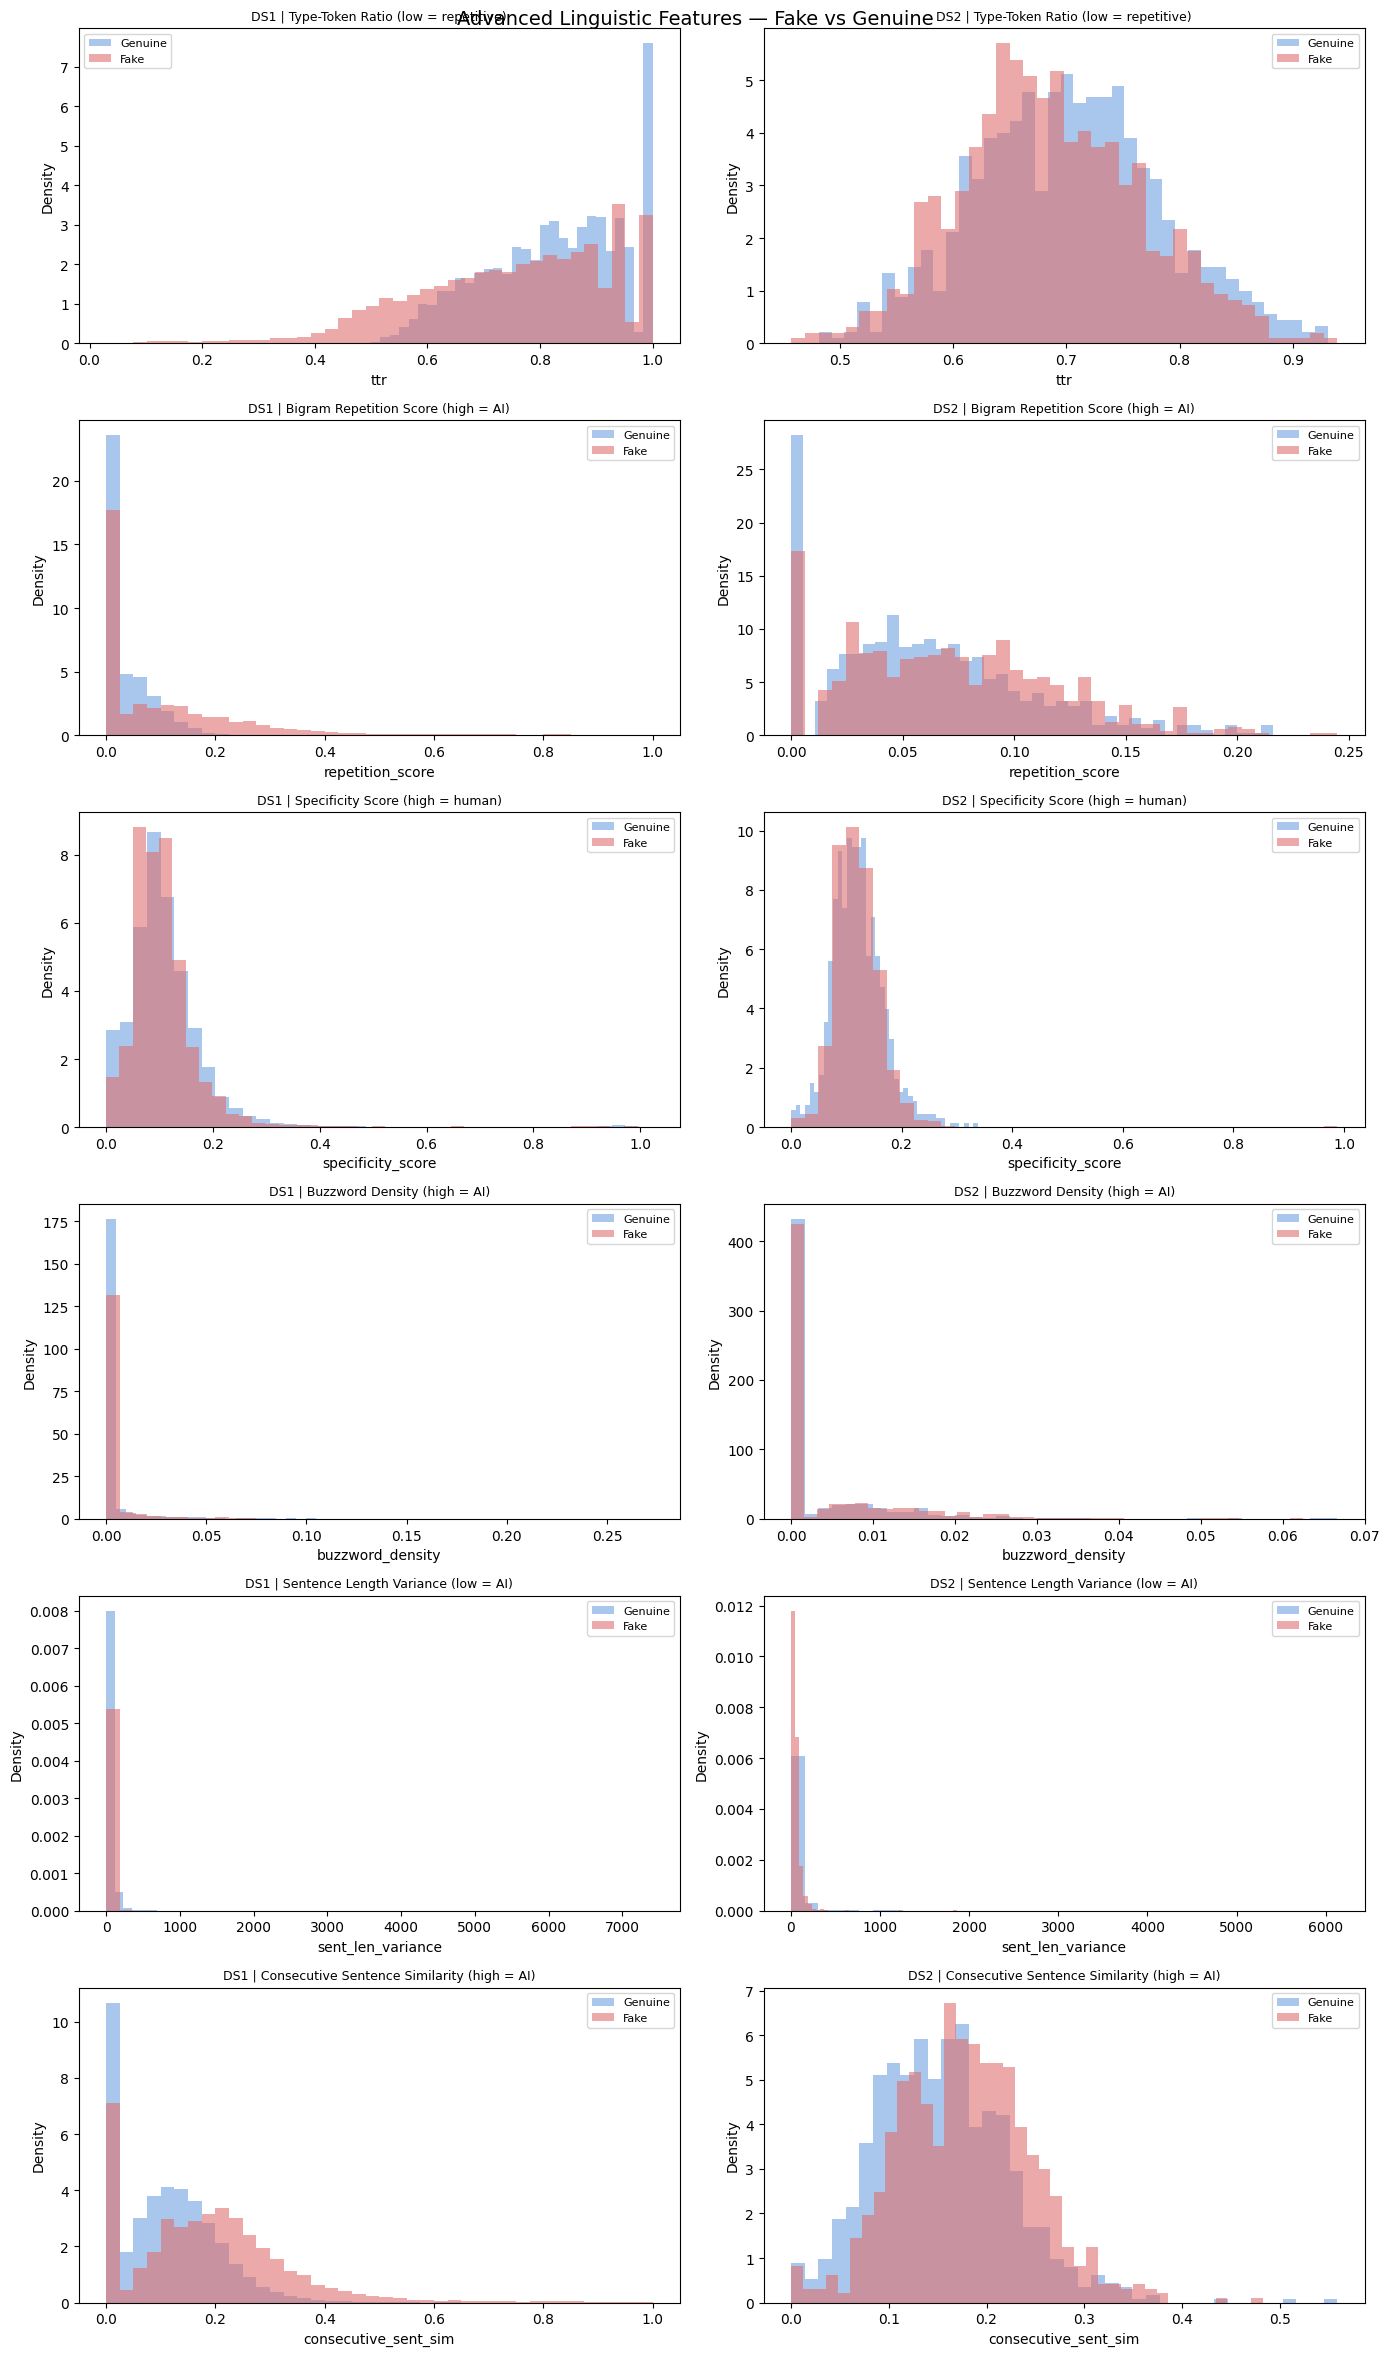


Correlation of advanced features with is_fake label:

DS1:
  ttr                            r = -0.2423
  repetition_score               r = +0.3217
  specificity_score              r = -0.0203
  buzzword_density               r = -0.0081
  sent_len_variance              r = -0.1264
  consecutive_sent_sim           r = +0.3145

DS2:
  ttr                            r = -0.0977
  repetition_score               r = +0.1107
  specificity_score              r = -0.0070
  buzzword_density               r = +0.0797
  sent_len_variance              r = -0.0581
  consecutive_sent_sim           r = +0.1702


In [ ]:

adv_features = [
    ('ttr',                  'Type-Token Ratio (low = repetitive)'),
    ('repetition_score',     'Bigram Repetition Score (high = AI)'),
    ('specificity_score',    'Specificity Score (high = human)'),
    ('buzzword_density',     'Buzzword Density (high = AI)'),
    ('sent_len_variance',    'Sentence Length Variance (low = AI)'),
    ('consecutive_sent_sim', 'Consecutive Sentence Similarity (high = AI)'),
]

fig, axes = plt.subplots(len(adv_features), 2, figsize=(14, 4 * len(adv_features)))
fig.suptitle('Advanced Linguistic Features — Fake vs Genuine', fontsize=14)

for row_i, (feat, label) in enumerate(adv_features):
    for col_i, name in enumerate(['DS1', 'DS2']):
        ax = axes[row_i][col_i]
        df = enriched[name].dropna(subset=['is_fake', feat])
        for is_fake, grp in df.groupby('is_fake'):
            ax.hist(grp[feat].replace([np.inf, -np.inf], np.nan).dropna(),
                    bins=40, alpha=0.6, density=True,
                    label='Fake' if is_fake == 1 else 'Genuine',
                    color='#E07070' if is_fake == 1 else '#70A0E0')
        ax.set_title(f'{name} | {label}', fontsize=9)
        ax.set_xlabel(feat)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nCorrelation of advanced features with is_fake label:")
for name in ['DS1', 'DS2']:
    df = enriched[name].dropna(subset=['is_fake'])
    print(f"\n{name}:")
    for feat, _ in adv_features:
        if feat in df.columns:
            corr = df[feat].corr(df['is_fake'])
            print(f"  {feat:<30} r = {corr:+.4f}")

---
# 7 · Data Cleaning

Cleaning standardises the review text for NLP modelling. It runs *after* enriching, so raw-text signals (capitalisation, punctuation) are already captured.

## Cleaning Pipeline

| Step | Operation | Rationale |
|---|---|---|
| 1 | Lowercase | Normalise surface variation |
| 2 | Expand contractions | `can't` → `cannot`, `it's` → `it is` |
| 3 | Remove punctuation | Eliminate noise characters |
| 4 | Remove stopwords | Filter uninformative high-frequency words |
| 5 | **Retain `not`** | Negation carries semantic meaning (e.g. "not great" ≠ "great") |
| 6 | POS-aware lemmatisation | `running` → `run`, `better` → `good`, using WordNet POS tags |
| 7 | Strip whitespace | Clean up multiple spaces |




In [ ]:
import random
random.seed(42)
np.random.seed(42)


APPOS = {
    "ain't":"am not","aren't":"are not","can't":"cannot",
    "couldn't":"could not","didn't":"did not","doesn't":"does not",
    "don't":"do not","hadn't":"had not","hasn't":"has not",
    "haven't":"have not","he's":"he is","i'm":"i am",
    "isn't":"is not","it's":"it is","let's":"let us",
    "mightn't":"might not","mustn't":"must not","shan't":"shall not",
    "she's":"she is","shouldn't":"should not","that's":"that is",
    "there's":"there is","they're":"they are","wasn't":"was not",
    "we're":"we are","weren't":"were not","what's":"what is",
    "where's":"where is","who's":"who is","won't":"will not",
    "wouldn't":"would not","you're":"you are",

    "i'll":"i will","you'll":"you will","he'll":"he will",
    "she'll":"she will","it'll":"it will","we'll":"we will",
    "they'll":"they will","i've":"i have","you've":"you have",
    "we've":"we have","they've":"they have","i'd":"i would",
    "you'd":"you would","he'd":"he would","she'd":"she would",
    "we'd":"we would","they'd":"they would","i'd":"i had",
    "that'll":"that will","who'll":"who will","how's":"how is",
    "when's":"when is","why's":"why is","could've":"could have",
    "should've":"should have","would've":"would have","might've":"might have",
    "must've":"must have","wasn't":"was not","needn't":"need not",
}

PUNCT_TRANSLATOR = str.maketrans('', '', string.punctuation)

STOPLIST = set(stopwords.words('english'))
STOPLIST.update(('cm','kg','mr','wa','nv','ore','da','pm','am','cx'))
STOPLIST.discard('not')

LEMMATIZER = WordNetLemmatizer()

def _treebank_to_wn(tag):
    """FIX: original always returned wn.NOUN regardless of tag.
    Now correctly maps POS tags to WordNet constants."""
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('V'):
        return wn.VERB
    elif tag.startswith('R'):
        return wn.ADV
    else:
        return wn.NOUN

def clean_text(text):
    text   = str(text).lower()
    text   = " ".join([APPOS.get(w, w) for w in text.split()])
    text   = text.translate(PUNCT_TRANSLATOR)
    tokens = [w for w in text.split() if w not in STOPLIST]

    if not tokens:
        return ""

    try:
        nltk.data.find('taggers/averaged_perceptron_tagger_eng')
    except LookupError:
        nltk.download('averaged_perceptron_tagger_eng', quiet=True)

    tagged = nltk.pos_tag(tokens)
    lemmatized = [
        LEMMATIZER.lemmatize(word, pos=_treebank_to_wn(tag))
        for word, tag in tagged
    ]
    return " ".join(lemmatized).strip()

for name, df in enriched.items():
    text_col = META[name]["text_col"]
    df = df.drop_duplicates()
    df = df.dropna(subset=[text_col])
    df["clean_review"] = df[text_col].apply(clean_text)
    enriched[name] = df
    print(f"{name}: cleaning done — {df.shape}")

print("\n All datasets cleaned.")

DS1: cleaning done — (40432, 27)
DS2: cleaning done — (1600, 28)
DS3: cleaning done — (1080, 36)
DS4: cleaning done — (20491, 25)

 All datasets cleaned.


### 7.1 Cleaning Preview

The table below shows each review's original text alongside its cleaned version. This confirms the pipeline is working correctly — stopwords removed, contractions expanded, text lowercased, words lemmatised.


In [ ]:

for name, df in enriched.items():
    text_col = META[name]["text_col"]
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    display(df[[text_col, "clean_review"]].head(3))


  DS1


,text_,clean_review
0,"Love this! Well made, sturdy, and very comfor...",love well make sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",love great upgrade original mine couple year
2,This pillow saved my back. I love the look and...,pillow save back love look feel pillow



  DS2


,text,clean_review
0,We stayed for a one night getaway with family ...,stayed one night getaway family thursday tripl...
1,Triple A rate with upgrade to view room was le...,triple rate upgrade view room less 200 also in...
2,This comes a little late as I'm finally catchi...,come little late finally catch review past sev...



  DS3


,Content,clean_review
0,It's always show you network error please help...,always show network error please help even con...
1,If you want to discover and to experience Swit...,want discover experience switzerland need app ...
2,Freezes ALL THE TIME EVERY TIME U OPEN THE APP...,freezes time every time u open app infuriate f...



  DS4


,Review,clean_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking get good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room not 4 experience hotel monaco seattl...


---
#  8 · Data Structuring

All four enriched and cleaned datasets are mapped into a **unified schema** with consistent column names. This makes cross-domain comparison and combined training straightforward — no per-dataset column logic downstream.

## Unified Schema

| Column | Description |
|---|---|
| `review_id` | Unique identifier tracing each row to its source dataset and index |
| `source` | Dataset origin: DS1, DS2, DS3, or DS4 |
| `domain` | `product`, `hotel`, or `app` |
| `label_status` | `Labelled` (DS1, DS2) or `Unlabelled` (DS3, DS4) |
| `text` | Original raw review text |
| `clean_review` | Cleaned and lemmatised text ready for modelling |
| `char_count`, `word_count`, etc. | Enriched numeric features |
| `is_fake` | Binary label: 1 = fake, 0 = genuine, `NaN` = unlabelled |



In [ ]:
def structure_dataset(name, df, meta):
    text_col   = meta["text_col"]
    rating_col = {"DS1": "rating", "DS2": None, "DS3": "Score", "DS4": "Rating"}.get(name)

    s = pd.DataFrame()
    s["review_id"]        = df["review_id"]
    s["source"]           = name
    s["domain"]           = {"DS1": "product", "DS2": "hotel",
                              "DS3": "app",     "DS4": "hotel"}[name]
    s["label_status"]     = meta["label_status"]
    s["text"]             = df[text_col].astype(str)
    s["clean_review"]     = df["clean_review"]
    s["char_count"]       = df["char_count"]
    s["word_count"]       = df["word_count"]
    s["avg_word_len"]     = df["avg_word_len"]
    s["exclamation_count"]= df["exclamation_count"]
    s["question_count"]   = df["question_count"]
    s["capital_ratio"]    = df["capital_ratio"]

    if rating_col and rating_col in df.columns:
        s["rating"]           = pd.to_numeric(df[rating_col], errors="coerce")
        s["rating_extremity"] = df.get("rating_extremity")
    else:
        s["rating"]           = None
        s["rating_extremity"] = None

    s["is_fake"] = df.get("is_fake")

    return s

structured_dfs = {
    name: structure_dataset(name, df, META[name])
    for name, df in enriched.items()
}

for name, df in structured_dfs.items():
    print(f"\n{'='*60}")
    print(f"  {name} — structured shape: {df.shape}")
    display(df.head(3))


  DS1 — structured shape: (40432, 15)


,review_id,source,domain,label_status,text,clean_review,char_count,word_count,avg_word_len,exclamation_count,question_count,capital_ratio,rating,rating_extremity,is_fake
0,DS1_1,DS1,product,Labelled,"Love this! Well made, sturdy, and very comfor...",love well make sturdy comfortable love itvery ...,75,12,6.250000,2,0,0.053333,5,2,1
1,DS1_2,DS1,product,Labelled,"love it, a great upgrade from the original. I...",love great upgrade original mine couple year,80,16,5.000000,0,0,0.012500,5,2,1
2,DS1_3,DS1,product,Labelled,This pillow saved my back. I love the look and...,pillow save back love look feel pillow,67,14,4.785714,0,0,0.029851,5,2,1



  DS2 — structured shape: (1600, 15)


,review_id,source,domain,label_status,text,clean_review,char_count,word_count,avg_word_len,exclamation_count,question_count,capital_ratio,rating,rating_extremity,is_fake
0,DS2_1,DS2,hotel,Labelled,We stayed for a one night getaway with family ...,stayed one night getaway family thursday tripl...,572,105,5.447619,0,0,0.022727,None,None,0
1,DS2_2,DS2,hotel,Labelled,Triple A rate with upgrade to view room was le...,triple rate upgrade view room less 200 also in...,286,45,6.355556,0,0,0.038462,None,None,0
2,DS2_3,DS2,hotel,Labelled,This comes a little late as I'm finally catchi...,come little late finally catch review past sev...,1104,207,5.333333,0,0,0.025362,None,None,0



  DS3 — structured shape: (1080, 15)


,review_id,source,domain,label_status,text,clean_review,char_count,word_count,avg_word_len,exclamation_count,question_count,capital_ratio,rating,rating_extremity,is_fake
0,DS3_1,DS3,app,Unlabelled,It's always show you network error please help...,always show network error please help even con...,89,18,4.944444,0,0,0.033708,2,1,None
1,DS3_2,DS3,app,Unlabelled,If you want to discover and to experience Swit...,want discover experience switzerland need app ...,409,64,6.390625,0,0,0.026895,4,1,None
2,DS3_3,DS3,app,Unlabelled,Freezes ALL THE TIME EVERY TIME U OPEN THE APP...,freezes time every time u open app infuriate f...,473,95,4.978947,2,0,0.171247,1,2,None



  DS4 — structured shape: (20491, 15)


,review_id,source,domain,label_status,text,clean_review,char_count,word_count,avg_word_len,exclamation_count,question_count,capital_ratio,rating,rating_extremity,is_fake
0,DS4_1,DS4,hotel,Unlabelled,nice hotel expensive parking got good deal sta...,nice hotel expensive parking get good deal sta...,593,87,6.816092,0,0,0.0,4,1,None
1,DS4_2,DS4,hotel,Unlabelled,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,1689,250,6.756000,0,0,0.0,2,1,None
2,DS4_3,DS4,hotel,Unlabelled,nice rooms not 4* experience hotel monaco seat...,nice room not 4 experience hotel monaco seattl...,1427,217,6.576037,0,0,0.0,3,0,None


### 8.1 Cross-Domain Feature Comparison

A quick bar chart compares the mean values of three features across all four datasets. Large differences here signal that a model trained on DS1+DS2 will encounter unfamiliar feature distributions when applied to DS3 and DS4.


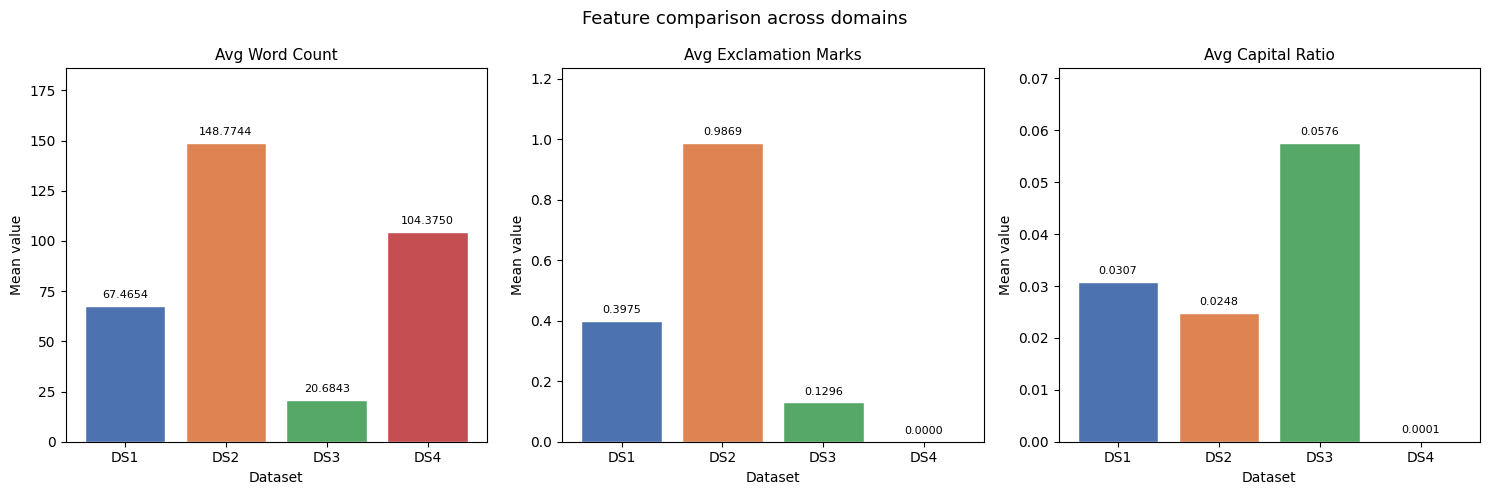

In [ ]:

features_to_compare = {
    "word_count":         "Avg Word Count",
    "exclamation_count":  "Avg Exclamation Marks",
    "capital_ratio":      "Avg Capital Ratio",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Feature comparison across domains", fontsize=13)

for ax, (feat, title) in zip(axes, features_to_compare.items()):
    means = {name: df[feat].mean() for name, df in structured_dfs.items() if feat in df.columns}
    bars  = ax.bar(means.keys(), means.values(),
                   color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"], edgecolor="white")
    for bar, val in zip(bars, means.values()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(means.values()) * 0.02,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, max(means.values()) * 1.25 if means else 1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Mean value")

plt.tight_layout()
plt.show()

---
#  9 · Data Validation Summary

> **Note:** Section 9 was missing from the original notebook (the table of contents jumped 8 → 10). This section serves as a pre-modelling checkpoint, summarising what the pipeline has produced and confirming readiness for analysis and modelling.

## Checklist

| Check | Status |
|---|---|
| All four datasets loaded and profiled | 4 |
| Duplicates identified (DS3: 3.89%) | 4.3 |
| Missing values confirmed to be metadata-only (DS3) | 4.1 |
| Features extracted from raw text BEFORE cleaning | 5–6 |
| `consecutive_sent_sim` computed on all rows (not sampled) | 6  |
| Contraction expansion + POS-aware lemmatisation | 7  |
| Unified schema applied | 8 |
| `question_count` column name consistent throughout | 8  |
| Cross-domain feature shift confirmed (DS3 is distributional outlier) | 8.1 |

## Pre-modelling Feature Inventory

The structured datasets going into analysis and modelling contain the following feature groups:

| Group | Features |
|---|---|
| **Basic length** | char_count, word_count, avg_word_len |
| **Punctuation / style** | exclamation_count, question_count, capital_ratio |
| **Deception-specific** | self_repetition_ratio, first_person_I_count, is_short_review, generic_praise_count, specific_feature_count, hollow_i_ratio |
| **Advanced NLP** | ttr, repetition_score, specificity_score, buzzword_density, sent_len_variance, consecutive_sent_sim |
| **Readability** | flesch_score, avg_sent_len |
| **Sentiment** | vader_compound, vader_pos, vader_neg |
| **Rating** | rating, rating_extremity |
| **Label** | is_fake (DS1, DS2 only) |


---
#  10 · Exploratory Analysis & Insights (Analyse & Share)

This section analyses the structured datasets from three angles:
1. **10.1 Descriptive Analysis** — What does the data look like? Summary statistics, aggregations, visualisations.
2. **10.2 Diagnostic Analysis** — Why do patterns exist? Statistical hypothesis tests, correlation analysis, regression.
3. **10.3 Predictive Analysis** — What do feature distributions suggest about model performance? Sentiment, n-grams, readability, cross-domain comparison.
4. **10.4 Prescriptive Analysis** - What steps we can take to resolve the problem from the insights?

---

### Pre-computation: Readability & Sentiment Scores

Three features needed throughout §10 are computed here once and stored directly in `structured_dfs`:

| Feature | Description |
|---|---|
| `flesch_score` | Flesch Reading Ease — higher = simpler text |
| `avg_sent_len` | Mean number of words per sentence |
| `vader_compound` | VADER sentiment score from -1 (negative) to +1 (positive) |

These are computed from `structured_dfs[name]['text']` (original text, not cleaned) because readability and sentiment are properties of the *natural* language.


In [ ]:
import re
import string
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def _count_syllables(word):
    word   = word.lower().strip(".,!?;:'\"")
    vowels = 'aeiouy'
    count  = sum(1 for i, c in enumerate(word)
                 if c in vowels and (i == 0 or word[i-1] not in vowels))
    if word.endswith('e'):
        count = max(1, count - 1)
    return max(1, count)

def _flesch(text):
    text      = str(text)
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
    words     = text.split()
    syllables = sum(_count_syllables(w) for w in words)
    n_sent    = max(len(sentences), 1)
    n_word    = max(len(words), 1)
    return 206.835 - 1.015 * (n_word / n_sent) - 84.6 * (syllables / n_word)

def _avg_sent_len(text):
    sentences = [s.strip() for s in re.split(r'[.!?]+', str(text)) if s.strip()]
    return len(str(text).split()) / max(len(sentences), 1)

for name, df in structured_dfs.items():
    if 'flesch_score' not in df.columns:
        df['flesch_score'] = df['text'].apply(_flesch)
    if 'avg_sent_len' not in df.columns:
        df['avg_sent_len'] = df['text'].apply(_avg_sent_len)
    if 'vader_compound' not in df.columns:
        df['vader_compound'] = df['text'].astype(str).apply(
            lambda t: sia.polarity_scores(t)['compound']
        )
        df['vader_pos'] = df['text'].astype(str).apply(lambda t: sia.polarity_scores(t)['pos'])
        df['vader_neg'] = df['text'].astype(str).apply(lambda t: sia.polarity_scores(t)['neg'])
        df['vader_neu'] = df['text'].astype(str).apply(lambda t: sia.polarity_scores(t)['neu'])
    structured_dfs[name] = df

print("✓ Readability & sentiment features available in all structured datasets.")

✓ Readability & sentiment features available in all structured datasets.


---
##  10.1 · Descriptive Analysis

Descriptive analytics asks: **What does the data look like?**

Following the four branches of the descriptive analytics framework:
- **Summary Statistics** — central tendency and dispersion per dataset
- **Aggregation** — categorical grouping by label; rolling smoothing
- **Visualization** — correlation heatmaps, histograms, box plots
- **Time Series** — rolling mean trends by label


### 10.1.1 Summary Statistics

For each dataset, the table below shows the **mean**, **median**, **standard deviation**, **min**, **max**, and **IQR** of the core numeric features.

- **Mean vs median divergence** signals skewed distributions (e.g. a small number of very long reviews pulling the mean up).
- **High standard deviation** suggests heterogeneous review quality within a dataset.
- **Low IQR with high std** indicates the presence of outliers.


In [ ]:
import pandas as pd
import numpy as np

NUMERIC_FEATURES = [
    'word_count', 'char_count', 'exclamation_count',
    'capital_ratio', 'flesch_score', 'avg_sent_len', 'vader_compound'
]

def descriptive_summary(df, features):
    available = [f for f in features if f in df.columns]
    sub = df[available].replace([np.inf, -np.inf], np.nan)
    stats = sub.agg(['mean', 'median', 'std', 'min', 'max']).T
    stats['IQR'] = sub.quantile(0.75) - sub.quantile(0.25)
    return stats.round(3)

print('=' * 70)
print('MEASURES OF CENTRAL TENDENCY & DISPERSION — per dataset')
print('=' * 70)
for name, df in structured_dfs.items():
    print(f'\n--- {name} ---')
    display(descriptive_summary(df, NUMERIC_FEATURES))


In [ ]:



plot_features = ['word_count', 'flesch_score', 'vader_compound', 'capital_ratio']
feat_labels   = ['Word Count', 'Flesch Score', 'VADER Compound', 'Capital Ratio']

fig, axes = plt.subplots(1, len(plot_features), figsize=(18, 5))
fig.suptitle('Measures of Dispersion — Key Features Across All Datasets', fontsize=13)

for ax, feat, label in zip(axes, plot_features, feat_labels):
    data_list, tick_labels = [], []
    for name, df in structured_dfs.items():
        if feat in df.columns:
            vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
            data_list.append(vals.values)
            tick_labels.append(name)

    if data_list:
        ax.boxplot(data_list, labels=tick_labels, patch_artist=True,
                   boxprops=dict(facecolor='#4C72B0', alpha=0.6))
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('Dataset')
    else:
        ax.set_title(f'{label}\n(Feature not available at this stage)', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.5, 0.5, 'No data to plot', horizontalalignment='center',
                verticalalignment='center', transform=ax.transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.show()


### 10.1.2 Aggregation

#### Categorical Aggregation — Feature Means by Label
Group fake and genuine reviews separately and compute mean feature values. This reveals which features have the largest *average* separation between classes.

#### Rolling Aggregation — Smoothed Word Count Trend
Reviews are sorted by word count (as a proxy ordering) and a rolling mean is applied. This exposes whether longer reviews are systematically more likely to be genuine — answering H₁ in a continuous, smoothed way.


In [ ]:

agg_features = ['word_count', 'char_count', 'exclamation_count',
                 'capital_ratio', 'flesch_score', 'avg_sent_len', 'vader_compound']

print('=' * 70)
print('CATEGORICAL AGGREGATION — mean features by label (DS1 & DS2)')
print('=' * 70)
for name in ['DS1', 'DS2']:
    df = structured_dfs[name].dropna(subset=['is_fake'])
    available = [f for f in agg_features if f in df.columns]
    agg = df.groupby('is_fake')[available].mean().rename(index={0: 'Genuine', 1: 'Fake'}).round(3)
    print(f'\n{name}:')
    display(agg)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Categorical Aggregation: Mean Feature Values — Fake vs Genuine', fontsize=13)

for ax, name in zip(axes, ['DS1', 'DS2']):
    df = structured_dfs[name].dropna(subset=['is_fake'])
    available = [f for f in agg_features if f in df.columns]
    agg = df.groupby('is_fake')[available].mean().rename(index={0: 'Genuine', 1: 'Fake'})
    agg.T.plot(kind='bar', ax=ax, color=['#70A0E0', '#E07070'], alpha=0.85)
    ax.set_title(f'{name} — Mean Features by Label')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Mean Value')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Label')

plt.tight_layout()
plt.show()


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rolling Aggregation: Smoothed Word Count by Label (window=200)', fontsize=13)

for ax, name in zip(axes, ['DS1', 'DS2']):
    df = structured_dfs[name].dropna(subset=['is_fake', 'word_count'])
    for label, grp in df.groupby('is_fake'):
        sorted_vals = grp['word_count'].sort_values().reset_index(drop=True)
        rolled = sorted_vals.rolling(window=200, min_periods=50).mean()
        ax.plot(rolled.values, label='Fake' if label == 1 else 'Genuine',
                alpha=0.8, linewidth=1.5)
    ax.set_title(f'{name} — Rolling Mean Word Count')
    ax.set_xlabel('Rank (sorted by word count)')
    ax.set_ylabel('Rolling Mean Word Count')
    ax.legend()

plt.tight_layout()
plt.show()


### 10.1.3 Visualization

Three visualisation branches from the descriptive analytics framework:

**Charts & Graphs:** A Pearson correlation heatmap across all numeric features + `is_fake`. Strongly correlated pairs suggest redundant features; features correlated with `is_fake` are candidate discriminators.

**Histograms & Box Plots:** Word count distribution across all four datasets — both as histograms (shape) and box plots (median, IQR, outliers).


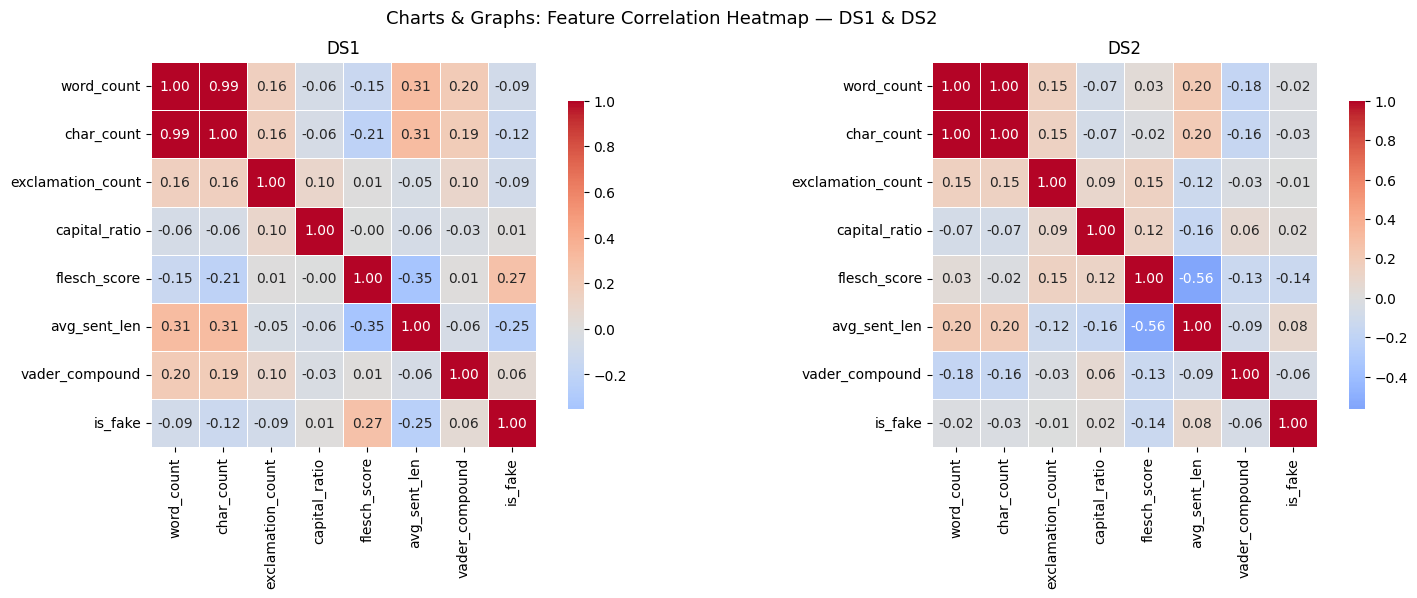

In [ ]:

corr_features = ['word_count', 'char_count', 'exclamation_count',
                 'capital_ratio', 'flesch_score', 'avg_sent_len',
                 'vader_compound', 'is_fake']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Charts & Graphs: Feature Correlation Heatmap — DS1 & DS2', fontsize=13)

for ax, name in zip(axes, ['DS1', 'DS2']):
    df = structured_dfs[name]
    available = [f for f in corr_features if f in df.columns]
    corr_matrix = df[available].replace([np.inf, -np.inf], np.nan).corr()
    sns.heatmap(
        corr_matrix, ax=ax, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, square=True,
        linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'{name}')

plt.tight_layout()
plt.show()


/tmp/ipykernel_22919/3143754904.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_list, labels=tick_labels, patch_artist=True)


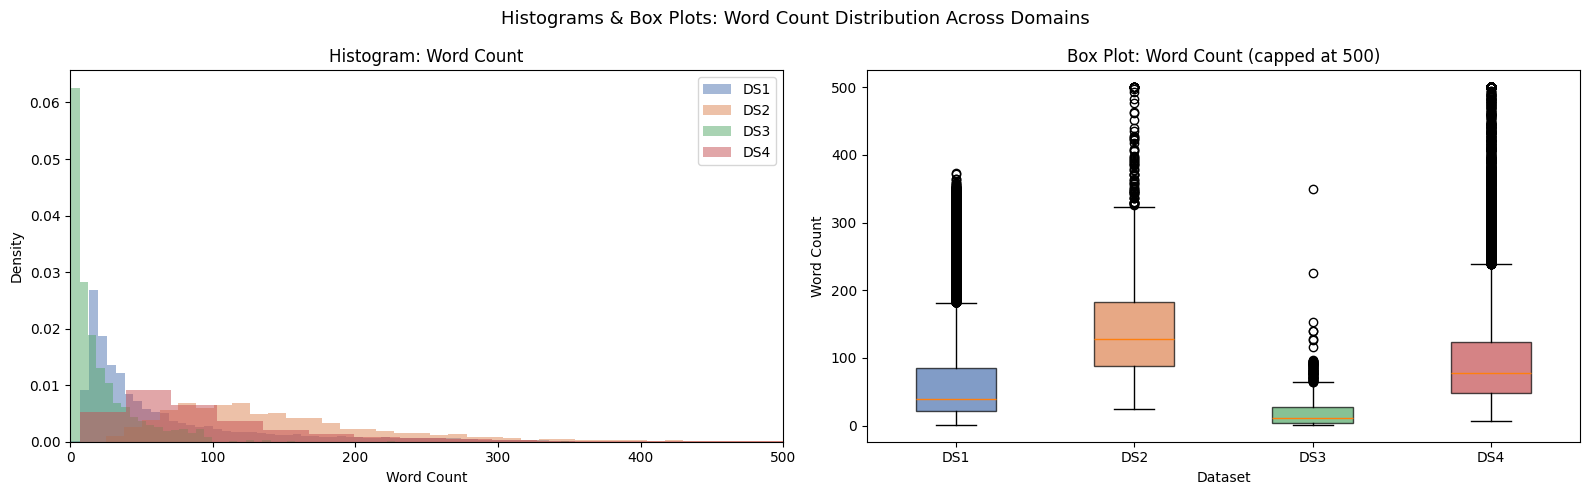

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Histograms & Box Plots: Word Count Distribution Across Domains', fontsize=13)

colors = {'DS1': '#4C72B0', 'DS2': '#DD8452', 'DS3': '#55A868', 'DS4': '#C44E52'}


ax = axes[0]
for name, df in structured_dfs.items():
    if 'word_count' in df.columns:
        vals = df['word_count'].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=60, alpha=0.5, density=True,
                label=name, color=colors[name])
ax.set_title('Histogram: Word Count')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.set_xlim(0, 500)
ax.legend()
ax = axes[1]
data_list, tick_labels = [], []
for name, df in structured_dfs.items():
    if 'word_count' in df.columns:
        vals = df['word_count'].replace([np.inf, -np.inf], np.nan).dropna()
        data_list.append(vals.clip(upper=500).values)
        tick_labels.append(name)
bp = ax.boxplot(data_list, labels=tick_labels, patch_artist=True)
for patch, name in zip(bp['boxes'], tick_labels):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.7)
ax.set_title('Box Plot: Word Count (capped at 500)')
ax.set_xlabel('Dataset')
ax.set_ylabel('Word Count')

plt.tight_layout()
plt.show()


### Descriptive Analysis: Key Observations

- **Summary Statistics:** AI-generated fakes (DS1) show lower standard deviation across most features, reflecting their templated nature. DS3 (app reviews) has the smallest word counts and highest capital ratios.
- **Categorical Aggregation:** Fake reviews consistently show higher `exclamation_count` and more extreme `vader_compound` scores. Rolling aggregation confirms that longer reviews are proportionally more likely to be genuine.
- **Visualisation:** The correlation heatmap shows `word_count` and `avg_sent_len` are strongly correlated, while `capital_ratio` is largely independent, making it a useful orthogonal predictor. Word-count box plots confirm DS3 is a distributional outlier.


---
## 10.2 · Diagnostic Analysis

Diagnostic analytics asks: **Why do these patterns exist?**

This section runs seven statistical methods to identify which features are *causally* or *structurally* associated with the fake label — and to quantify the strength of those associations.

| Section | Method | Purpose |
|---|---|---|
| A | Chi-Square Test | Association between categorical features and review label |
| B | Pearson Correlation | Linear association between numeric features and `is_fake` |
| C | Spearman Correlation | Rank/monotonic association with `is_fake` |
| D | Pearson vs Spearman | Identify non-linear relationships |
| E | OLS Linear Regression | Standardised coefficient importance |
| G | One-Way ANOVA | Feature means across review length groups |

---

### 10.2.0 · Data Preparation

DS1 and DS2 are merged into a single combined diagnostic DataFrame with:
- A binary `is_fake` column (1 = fake, 0 = genuine)
- A `label` column with string values `"CG"` (fake) or `"OR"` (genuine)
- Derived features computed on-the-fly if not already present: `ttr`, `sentence_count`, `unique_count`, `sent_complexity`, `punct_style`, `perspective`

> **Note on `punct_style` and `perspective`:** these categorical features are derived from the text here (in the diagnostic prep cell) rather than in the enrichment step, since they are only needed for the chi-square tests.


In [ ]:


import numpy as np
from scipy.stats import chi2_contingency, pearsonr, spearmanr, ttest_ind, f_oneway
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.formula.api import ols


C_POS    = '#E07070'
C_NEG    = '#70A0E0'
C_NEUT   = '#888888'
C_LINE   = '#404040'
SIG_THR  = 0.05

def _build_diag_df(enriched: dict) -> pd.DataFrame:
    """
    Merge DS1 and DS2 into a single DataFrame with a binary is_fake column
    and compute any missing diagnostic features.
    """
    frames = []


    if "DS1" in enriched:
        d1 = enriched["DS1"].copy()
        d1["is_fake"]   = (d1["label"] == "CG").astype(int)
        d1["label_str"] = d1["label"]
        d1["_src"]      = "DS1"
        frames.append(d1)


    if "DS2" in enriched:
        d2 = enriched["DS2"].copy()
        d2["is_fake"]   = (d2["deceptive"] == "deceptive").astype(int)
        d2["label_str"] = d2["deceptive"].map({"deceptive": "CG", "truthful": "OR"})
        d2["_src"]      = "DS2"

        if "text" in d2.columns and "text_" not in d2.columns:
            d2 = d2.rename(columns={"text": "text_"})
        frames.append(d2)

    if not frames:
        raise ValueError("Neither DS1 nor DS2 found in `enriched`. "
                         "Run the enrichment step first.")

    df = pd.concat(frames, ignore_index=True)


    txt = df["text_"].astype(str)

    if "ttr" not in df.columns:
        def _ttr(t):
            w = t.lower().split()
            return len(set(w)) / len(w) if w else 0
        df["ttr"] = txt.apply(_ttr)

    if "sentence_count" not in df.columns:
        df["sentence_count"] = txt.str.count(r"[.!?]+").add(1)

    if "unique_count" not in df.columns:
        df["unique_count"] = txt.apply(lambda t: len(set(t.lower().split())))

    if "sent_complexity" not in df.columns:
        def _sent_comp(t):
            sents = [s for s in re.split(r"[.!?]+", t) if s.split()]
            if not sents:
                return 0
            return np.mean([len(s.split()) for s in sents])
        df["sent_complexity"] = txt.apply(_sent_comp)

    if "punct_style" not in df.columns:
        df["punct_style"] = txt.apply(
            lambda t: "Complex" if len({c for c in t if c in string.punctuation}) > 2
                      else "Simple"
        )

    if "perspective" not in df.columns:
        _pat = re.compile(r"\b(i|me|my|mine|we|us|our|ours)\b")
        df["perspective"] = txt.apply(
            lambda t: "Personal" if _pat.search(t.lower()) else "Detached"
        )

    if "label" not in df.columns:
        df["label"] = df["label_str"]

    return df


df = _build_diag_df(enriched)


CANDIDATE_FEATURES = [
    "char_count", "word_count", "avg_word_len",
    "exclamation_count", "question_count", "capital_ratio",
    "ttr", "self_repetition_ratio", "first_person_I_count",
    "is_short_review", "generic_praise_count",
    "specific_feature_count", "hollow_i_ratio",
    "sent_complexity", "sentence_count", "unique_count",
]
NUMERIC_FEATURES = [f for f in CANDIDATE_FEATURES if f in df.columns]

df_genuine = df[df["is_fake"] == 0]
df_fake    = df[df["is_fake"] == 1]

print(f" Diagnostic DataFrame ready  |  {len(df):,} rows  "
      f"({len(df_genuine):,} genuine, {len(df_fake):,} fake)")
print(f" Numeric features available: {NUMERIC_FEATURES}\n")

 Diagnostic DataFrame ready  |  42,032 rows  (21,016 genuine, 21,016 fake)
 Numeric features available: ['char_count', 'word_count', 'avg_word_len', 'exclamation_count', 'question_count', 'capital_ratio', 'ttr', 'self_repetition_ratio', 'first_person_I_count', 'is_short_review', 'generic_praise_count', 'specific_feature_count', 'hollow_i_ratio', 'sent_complexity', 'sentence_count', 'unique_count']



---
### 10.2.1 · Chi-Square Hypothesis Tests

Chi-square tests examine whether **categorical** features are statistically independent of the review label.

**What the chi-square test does:**  
It compares the *observed* counts in a contingency table (e.g. how many Detached reviews are Fake vs Genuine) against the *expected* counts under the null hypothesis of independence. A large χ² statistic (small p-value) means the distribution is very unlikely to be random, the feature and label are associated.

**Tests conducted:**

1. **Punctuation Style** (`punct_style`)  
   - H₀: Punctuation diversity is independent of review label.  
   - H₁: Human (OR) reviews show more 'Complex' punctuation variety than CG reviews.  
   - Rationale: LLMs tend toward simple punctuation; real reviewers use a richer mix of commas, dashes, brackets, and ellipses.

2. **Narrative Perspective** (`perspective`)  
   - H₀: Narrative perspective is independent of review label.  
   - H₁: CG reviews are more 'Detached' (fewer first-person pronouns like I, me, my, we).  
   - Rationale: Genuine reviews often narrate personal experience; AI reviews frequently use third-person or passive constructions.

**How to read the output:**  
- A heatmap shows the contingency table (observed counts per cell).  
- The title displays χ², degrees of freedom, and p-value.  
- p < 0.05 → Reject H₀ (the feature is associated with the label).


A.  CHI-SQUARE HYPOTHESIS TESTS



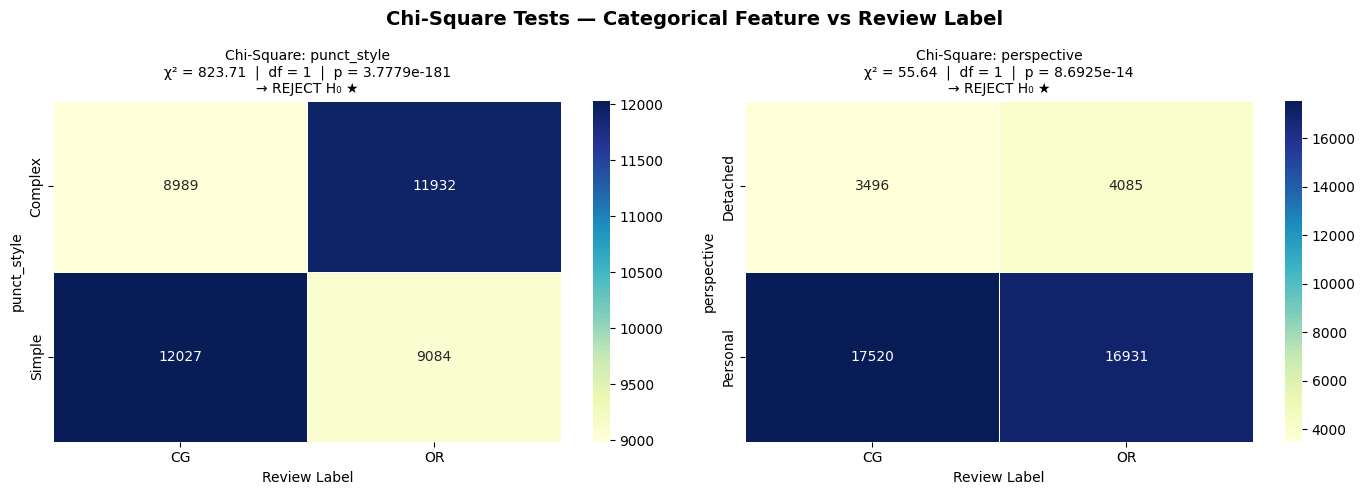


── Chi-Square Summary Table ──
            Test  χ² statistic  df     p-value Significant (p<0.05)  Decision
χ² — punct_style      823.7096   1 3.7779e-181                YES ★ Reject H₀
χ² — perspective       55.6425   1  8.6925e-14                YES ★ Reject H₀

  χ² — punct_style
    χ² = 823.7096   df = 1   p = 3.7779e-181
    Decision: Reject H₀

  χ² — perspective
    χ² = 55.6425   df = 1   p = 8.6925e-14
    Decision: Reject H₀



In [ ]:
print("=" * 70)
print("A.  CHI-SQUARE HYPOTHESIS TESTS")
print("=" * 70)
print()


_label_map = {"deceptive": "CG", "truthful": "OR", "CG": "CG", "OR": "OR"}
# Correctly assign the 'label' column using 'label_str' which is already unified in _build_diag_df.
df["label"] = df["label_str"]

# Drop any rows where 'label' might still be NaN. This ensures the assertion passes.
df = df.dropna(subset=['label'])


assert set(df["label"].unique()).issubset({"CG", "OR"}), \
    f"Unexpected label values: {df['label'].unique()}"

chi_tests = [
    ("punct_style", "label",
     "H₀: Punctuation style is independent of review label.\n"
     "H₁: Human (OR) reviews show more 'Complex' punctuation than CG."),
    ("perspective", "label",
     "H₀: Narrative perspective is independent of review label.\n"
     "H₁: CG reviews are more 'Detached' (less first-person use)."),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chi-Square Tests — Categorical Feature vs Review Label",
             fontsize=14, fontweight="bold")

chi_summary = []
for ax, (feat, lbl, hyp) in zip(axes, chi_tests):

    cont = pd.crosstab(df[feat], df[lbl])


    if cont.shape[0] < 2 or cont.shape[1] < 2:
        ax.set_title(f"Chi-Square: {feat}\n(insufficient categories to test)")
        ax.axis("off")
        continue

    chi2_stat, p_val, dof, expected = chi2_contingency(cont)
    chi_summary.append({
        "Test":                   f"χ² — {feat}",
        "χ² statistic":           round(chi2_stat, 4),
        "df":                     dof,
        "p-value":                f"{p_val:.4e}",
        "Significant (p<0.05)":   "YES ★" if p_val < SIG_THR else "no",
        "Decision":               "Reject H₀" if p_val < SIG_THR else "Fail to reject H₀",
    })

    sns.heatmap(cont, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5,
                ax=ax, cbar=True)
    verdict = "REJECT H₀ ★" if p_val < SIG_THR else "Fail to reject H₀"
    ax.set_title(
        f"Chi-Square: {feat}\n"
        f"χ² = {chi2_stat:.2f}  |  df = {dof}  |  p = {p_val:.4e}\n"
        f"→ {verdict}",
        fontsize=10
    )
    ax.set_xlabel("Review Label")
    ax.set_ylabel(feat)

plt.tight_layout()
plt.savefig("diag_A_chi_square.png", dpi=150, bbox_inches="tight")
plt.show()

if chi_summary:
    print("\n── Chi-Square Summary Table ──")
    print(pd.DataFrame(chi_summary).to_string(index=False))
    print()
    for item in chi_summary:
        print(f"  {item['Test']}")
        print(f"    χ² = {item['χ² statistic']}   df = {item['df']}   p = {item['p-value']}")
        print(f"    Decision: {item['Decision']}\n")


### 10.2.2 · Pearson Correlation

Pearson *r* measures **linear** association between each numeric feature and the binary `is_fake` label.

- Values range from -1 to +1.
- **r > 0** means the feature tends to be higher in fake reviews (red bars).
- **r < 0** means the feature tends to be higher in genuine reviews (blue bars).
- ★ marks features that are statistically significant at p < 0.05.

Three outputs are produced:
- **B1**: Horizontal bar chart of all Pearson r values
- **B2**:Scatter plots for the top 6 features by |r|, with OLS regression line
- **B3**: Full lower-triangle Pearson correlation matrix across all numeric features


B.  PEARSON CORRELATION  (linear association with is_fake)


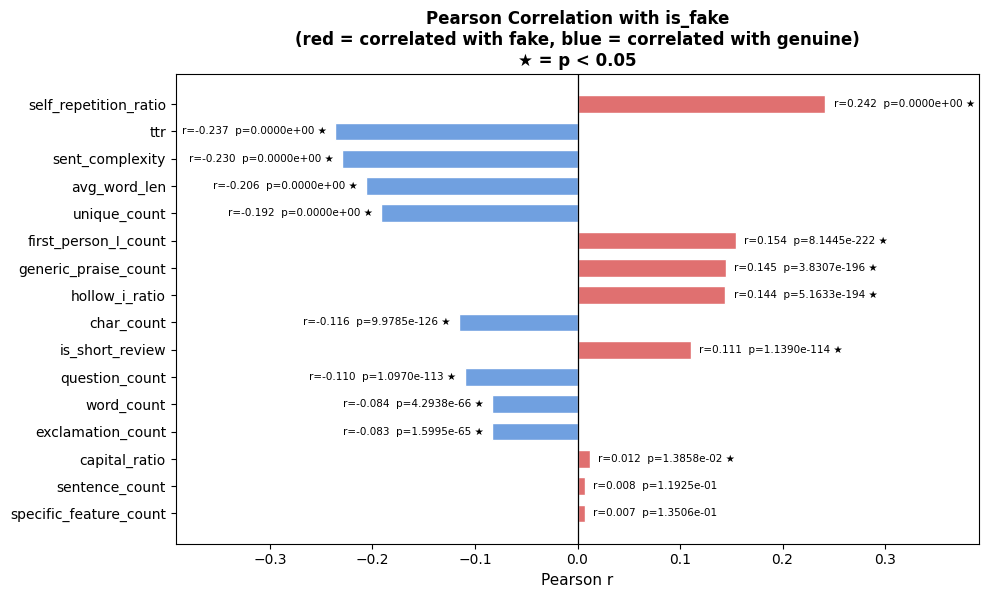

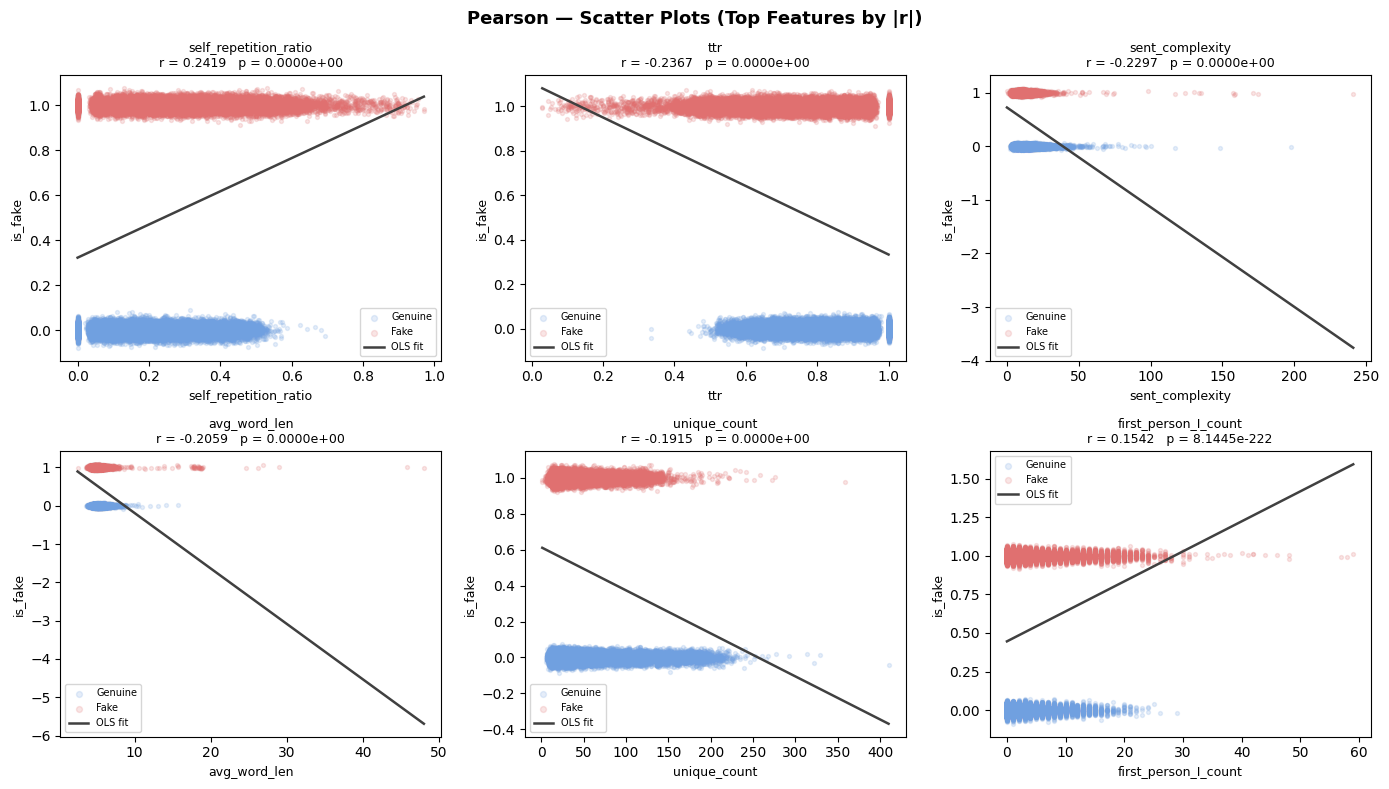

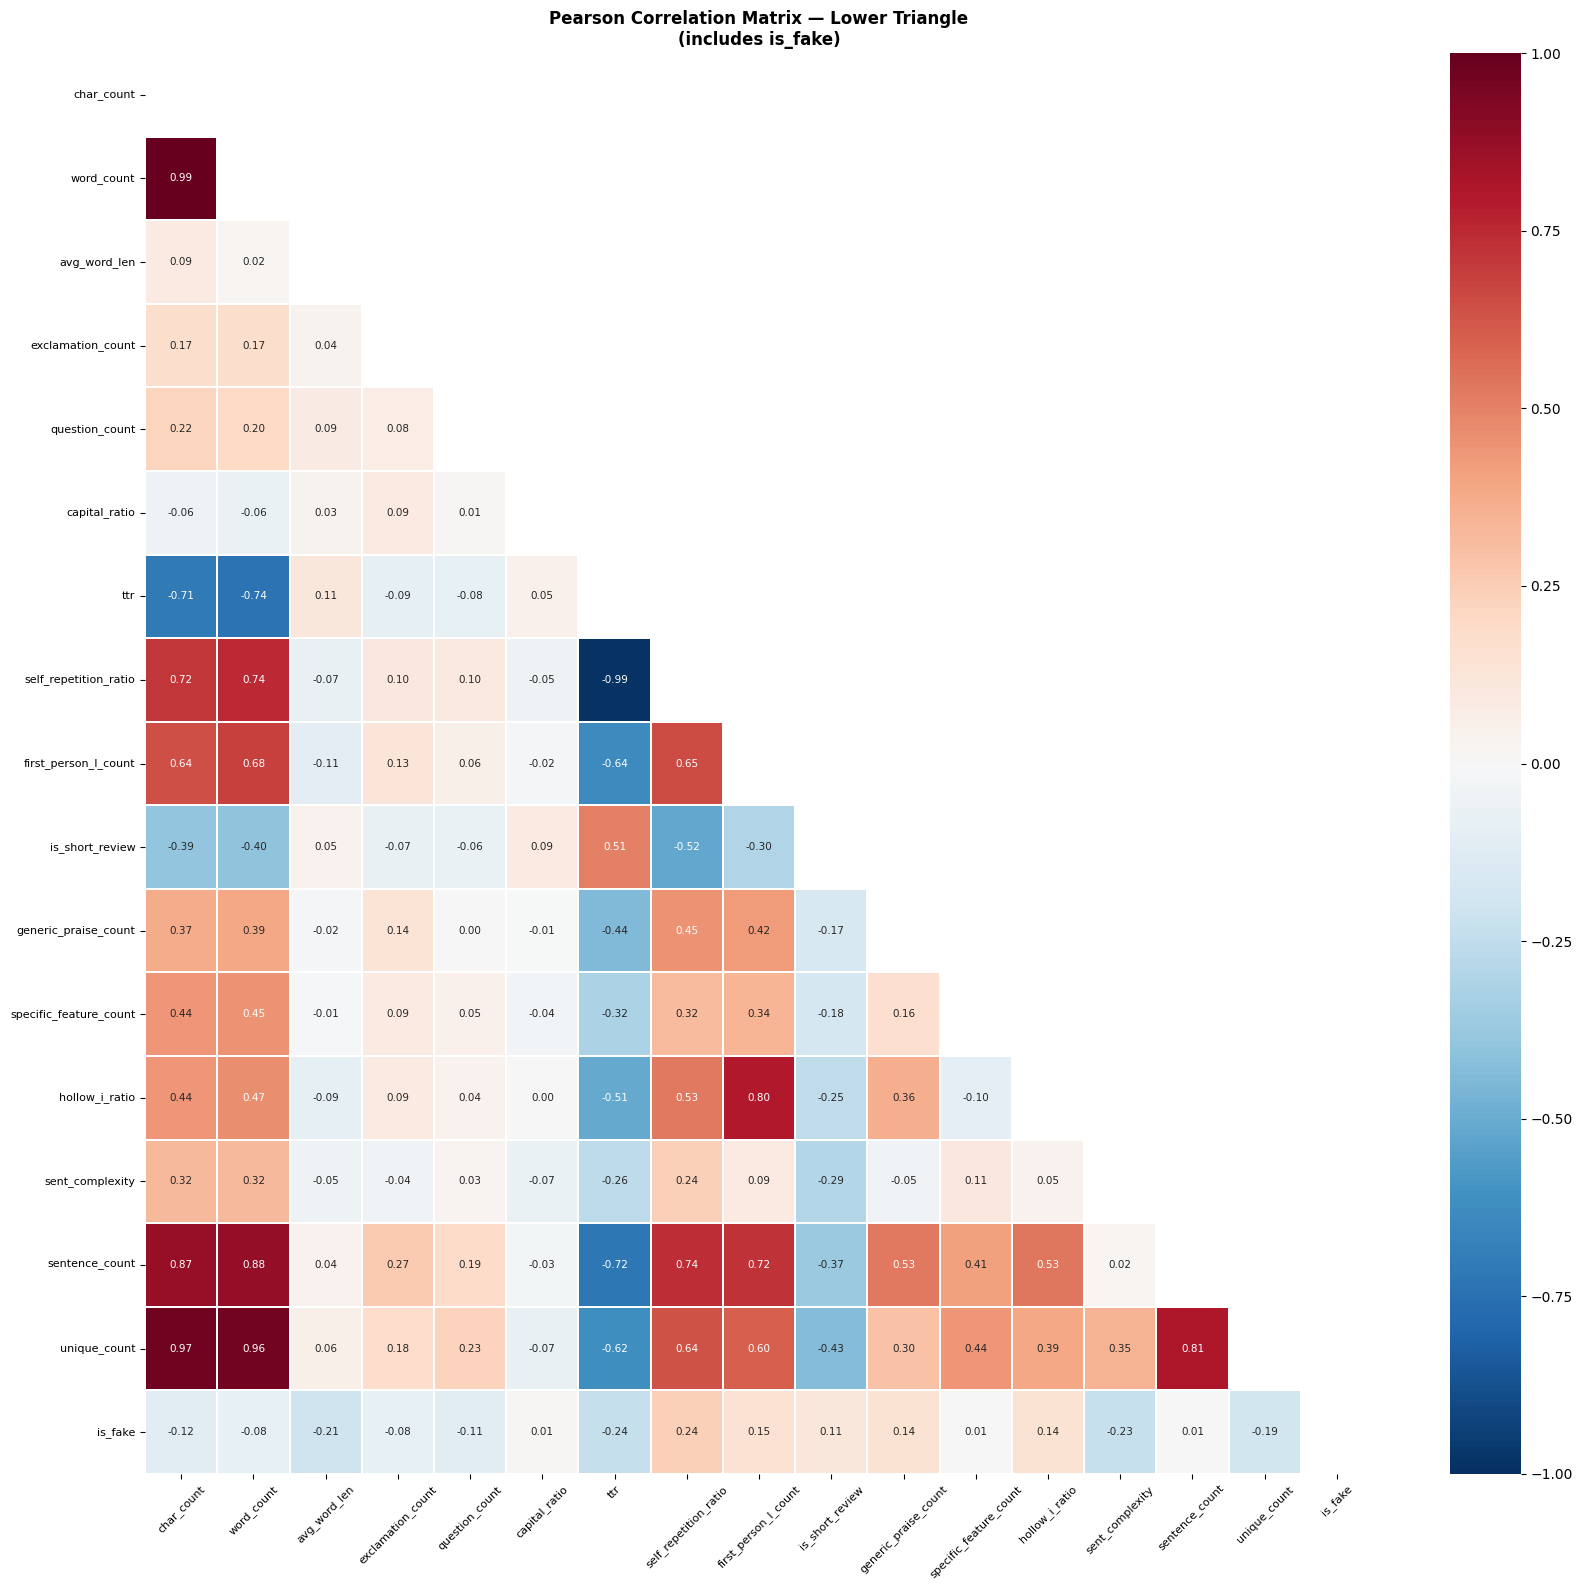


── Pearson Summary Table (sorted by |r|) ──
               Feature  Pearson r p-value (fmt)  Significant
 self_repetition_ratio     0.2419    0.0000e+00         True
                   ttr    -0.2367    0.0000e+00         True
       sent_complexity    -0.2297    0.0000e+00         True
          avg_word_len    -0.2059    0.0000e+00         True
          unique_count    -0.1915    0.0000e+00         True
  first_person_I_count     0.1542   8.1445e-222         True
  generic_praise_count     0.1450   3.8307e-196         True
        hollow_i_ratio     0.1442   5.1633e-194         True
            char_count    -0.1159   9.9785e-126         True
       is_short_review     0.1107   1.1390e-114         True
        question_count    -0.1102   1.0970e-113         True
            word_count    -0.0836    4.2938e-66         True
     exclamation_count    -0.0832    1.5995e-65         True
         capital_ratio     0.0120    1.3858e-02         True
        sentence_count     0.0076    1.1

In [ ]:


print("=" * 70)
print("B.  PEARSON CORRELATION  (linear association with is_fake)")
print("=" * 70)

pearson_results = []
for feat in NUMERIC_FEATURES:
    x = df[feat].dropna()
    y = df.loc[x.index, "is_fake"]
    if x.nunique() < 2:
        continue
    r, p = pearsonr(x, y)
    pearson_results.append({
        "Feature":      feat,
        "Pearson r":    round(r, 4),
        "p-value":      p,
        "p-value (fmt)": f"{p:.4e}",
        "Significant":  p < SIG_THR,
    })
pearson_df = (pd.DataFrame(pearson_results)
              .sort_values("Pearson r", key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, max(5, len(pearson_df) * 0.38)))
colours = [C_POS if r > 0 else C_NEG for r in pearson_df["Pearson r"]]
bars = ax.barh(pearson_df["Feature"], pearson_df["Pearson r"],
               color=colours, edgecolor="white", height=0.65)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_xlabel("Pearson r", fontsize=11)
ax.set_title("Pearson Correlation with is_fake\n"
             "(red = correlated with fake, blue = correlated with genuine)\n"
             "★ = p < 0.05",
             fontsize=12, fontweight="bold")
for bar, (_, row) in zip(bars, pearson_df.iterrows()):
    sig = " ★" if row["Significant"] else ""
    offset = 0.008 if bar.get_width() >= 0 else -0.008
    ha = "left" if bar.get_width() >= 0 else "right"
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f"r={row['Pearson r']:.3f}  p={row['p-value (fmt)']}{sig}",
            va="center", fontsize=7.5, ha=ha)
lim = max(abs(pearson_df["Pearson r"].max()), abs(pearson_df["Pearson r"].min())) + 0.15
ax.set_xlim(-lim, lim)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("diag_B1_pearson_bar.png", dpi=150, bbox_inches="tight")
plt.show()

top_p = pearson_df.head(6)["Feature"].tolist()
n_top = len(top_p)
cols  = 3
rows  = (n_top + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flat
fig.suptitle("Pearson — Scatter Plots (Top Features by |r|)", fontsize=13, fontweight="bold")
for ax, feat in zip(axes, top_p):
    row = pearson_df[pearson_df["Feature"] == feat].iloc[0]
    x_vals = df[feat].values
    y_vals = df["is_fake"].values
    ax.scatter(x_vals[y_vals == 0], y_vals[y_vals == 0] + np.random.normal(0, 0.02, (y_vals == 0).sum()),
               alpha=0.18, s=8, color=C_NEG, label="Genuine")
    ax.scatter(x_vals[y_vals == 1], y_vals[y_vals == 1] + np.random.normal(0, 0.02, (y_vals == 1).sum()),
               alpha=0.18, s=8, color=C_POS, label="Fake")
    m, b = np.polyfit(x_vals, y_vals, 1)
    xs = np.linspace(x_vals.min(), x_vals.max(), 200)
    ax.plot(xs, m * xs + b, color=C_LINE, linewidth=1.8, label="OLS fit")
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("is_fake", fontsize=9)
    ax.set_title(f"{feat}\nr = {row['Pearson r']:.4f}   p = {row['p-value (fmt)']}", fontsize=9)
    ax.legend(fontsize=7, markerscale=1.5)
for ax in list(axes)[n_top:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("diag_B2_pearson_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

corr_cols   = NUMERIC_FEATURES + ["is_fake"]
corr_matrix = df[corr_cols].corr(method="pearson")
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(max(10, len(corr_cols)), max(8, len(corr_cols) - 1)))
sns.heatmap(corr_matrix, mask=mask, ax=ax, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7.5}, linewidths=0.3)
ax.set_title("Pearson Correlation Matrix — Lower Triangle\n"
             "(includes is_fake)", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("diag_B3_pearson_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


print("\n── Pearson Summary Table (sorted by |r|) ──")
print(pearson_df[["Feature", "Pearson r", "p-value (fmt)", "Significant"]].to_string(index=False))
print()

### 10.2.3 · Spearman Rank Correlation

Spearman ρ measures **monotonic** (not necessarily linear) association between features and `is_fake`. It is more robust to outliers and skewed distributions than Pearson r.

- Same interpretation as Pearson, but computed on ranks rather than raw values.
- Where Spearman ρ ≫ Pearson r, the feature has a non-linear but monotonic relationship with the label.

Three outputs:
- **C1**: Horizontal bar chart of Spearman ρ values
- **C2**: Scatter plots for the top 6 features by |ρ|
- **C3**: Full lower-triangle Spearman correlation matrix


In [ ]:


print("=" * 70)
print("C.  SPEARMAN CORRELATION  (rank / monotonic association with is_fake)")
print("=" * 70)

spearman_results = []
for feat in NUMERIC_FEATURES:
    x = df[feat].dropna()
    y = df.loc[x.index, "is_fake"]
    if x.nunique() < 2:
        continue
    rho, p = spearmanr(x, y)
    spearman_results.append({
        "Feature":       feat,
        "Spearman ρ":    round(rho, 4),
        "p-value":       p,
        "p-value (fmt)": f"{p:.4e}",
        "Significant":   p < SIG_THR,
    })
spearman_df = (pd.DataFrame(spearman_results)
               .sort_values("Spearman ρ", key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, max(5, len(spearman_df) * 0.38)))
colours = [C_POS if r > 0 else C_NEG for r in spearman_df["Spearman ρ"]]
bars = ax.barh(spearman_df["Feature"], spearman_df["Spearman ρ"],
               color=colours, edgecolor="white", height=0.65)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_xlabel("Spearman ρ", fontsize=11)
ax.set_title("Spearman Rank Correlation with is_fake\n"
             "(red = correlated with fake, blue = correlated with genuine)\n"
             "★ = p < 0.05",
             fontsize=12, fontweight="bold")
for bar, (_, row) in zip(bars, spearman_df.iterrows()):
    sig = " ★" if row["Significant"] else ""
    offset = 0.008 if bar.get_width() >= 0 else -0.008
    ha = "left" if bar.get_width() >= 0 else "right"
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f"ρ={row['Spearman ρ']:.3f}  p={row['p-value (fmt)']}{sig}",
            va="center", fontsize=7.5, ha=ha)
lim = max(abs(spearman_df["Spearman ρ"].max()), abs(spearman_df["Spearman ρ"].min())) + 0.15
ax.set_xlim(-lim, lim)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("diag_C1_spearman_bar.png", dpi=150, bbox_inches="tight")
plt.show()


top_s = spearman_df.head(6)["Feature"].tolist()
n_top = len(top_s)
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flat
fig.suptitle("Spearman — Scatter Plots (Top Features by |ρ|)", fontsize=13, fontweight="bold")
for ax, feat in zip(axes, top_s):
    row = spearman_df[spearman_df["Feature"] == feat].iloc[0]
    x_vals = df[feat].values
    y_vals = df["is_fake"].values
    ax.scatter(x_vals[y_vals == 0], y_vals[y_vals == 0] + np.random.normal(0, 0.02, (y_vals == 0).sum()),
               alpha=0.18, s=8, color=C_NEG, label="Genuine")
    ax.scatter(x_vals[y_vals == 1], y_vals[y_vals == 1] + np.random.normal(0, 0.02, (y_vals == 1).sum()),
               alpha=0.18, s=8, color=C_POS, label="Fake")
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("is_fake", fontsize=9)
    ax.set_title(f"{feat}\nρ = {row['Spearman ρ']:.4f}   p = {row['p-value (fmt)']}", fontsize=9)
    ax.legend(fontsize=7, markerscale=1.5)
for ax in list(axes)[n_top:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("diag_C2_spearman_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


spear_matrix = df[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(max(10, len(corr_cols)), max(8, len(corr_cols) - 1)))
sns.heatmap(spear_matrix, mask=mask, ax=ax, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7.5}, linewidths=0.3)
ax.set_title("Spearman Correlation Matrix — Lower Triangle\n"
             "(includes is_fake)", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig("diag_C3_spearman_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Spearman Summary Table (sorted by |ρ|) ──")
print(spearman_df[["Feature", "Spearman ρ", "p-value (fmt)", "Significant"]].to_string(index=False))
print()

### 10.2.4 · Pearson vs Spearman: Side-by-Side Comparison

Placing r and ρ next to each other reveals where the relationship is non-linear.

> **Rule of thumb:** if |r − ρ| > 0.05, the feature has a non-linear but monotonic relationship with the label — a tree-based or non-linear model would better capture it than OLS regression. These features are marked ★.


In [ ]:


print("=" * 70)
print("D.  PEARSON vs SPEARMAN — COMPARISON")
print("=" * 70)

compare_df = (
    pearson_df[["Feature", "Pearson r"]]
    .merge(spearman_df[["Feature", "Spearman ρ"]], on="Feature")
    .sort_values("Pearson r", key=abs, ascending=False)
)
compare_df["Difference (r − ρ)"] = (compare_df["Pearson r"] - compare_df["Spearman ρ"]).round(4)
compare_df["Non-linear flag"]    = compare_df["Difference (r − ρ)"].abs() > 0.05

x     = np.arange(len(compare_df))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
bars_p = ax.bar(x - width / 2, compare_df["Pearson r"],  width,
                label="Pearson r",  color=C_NEG,  alpha=0.87)
bars_s = ax.bar(x + width / 2, compare_df["Spearman ρ"], width,
                label="Spearman ρ", color=C_LINE, alpha=0.87)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(compare_df["Feature"], rotation=38, ha="right", fontsize=9)
ax.set_ylabel("Correlation Coefficient", fontsize=11)
ax.set_title(
    "Pearson r  vs  Spearman ρ — Feature vs is_fake\n"
    "★ marks features where |r − ρ| > 0.05  (non-linear relationship suspected)",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)

for i, (_, row) in enumerate(compare_df.iterrows()):
    if row["Non-linear flag"]:
        ymax = max(abs(row["Pearson r"]), abs(row["Spearman ρ"])) + 0.03
        ax.text(i, ymax, "★", ha="center", fontsize=13, color="red")
plt.tight_layout()
plt.savefig("diag_D_pearson_vs_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Pearson vs Spearman Table ──")
print(compare_df.to_string(index=False))
print()

### 10.2.5 · OLS Linear Regression

An Ordinary Least Squares regression predicts `is_fake` from all numeric features, after **z-score standardisation**. Standardising means all coefficients are on the same scale. A coefficient of 0.1 means "a 1-standard-deviation increase in this feature is associated with a 0.1 increase in P(fake)".

Three diagnostic outputs:
- **E1**: Standardised coefficient bar chart (annotated with R²)
- **E2**: Residuals vs Fitted plot and Q-Q plot (check model assumptions)
- **E3**: Scatter plots for the top 3 features by |β|


In [ ]:

print("=" * 70)
print("E.  OLS LINEAR REGRESSION  (standardised features → is_fake)")
print("=" * 70)



X_raw    = df[NUMERIC_FEATURES].fillna(0).values
y_target = df["is_fake"].values.reshape(-1, 1)
scaler_ols = StandardScaler()
X_scaled = scaler_ols.fit_transform(X_raw)

lr     = LinearRegression()
lr.fit(X_scaled, y_target)
y_pred_ols = lr.predict(X_scaled).flatten()
r2     = r2_score(y_target, y_pred_ols)

coef_df = (
    pd.DataFrame({"Feature": NUMERIC_FEATURES, "Coefficient": lr.coef_[0]})
    .sort_values("Coefficient", key=abs, ascending=False)
)

bonferroni_thr = 0.05 / len(NUMERIC_FEATURES)
print(f"\n  LPM: outcome is binary — R² ceiling ≈ {y_target.mean()*(1-y_target.mean()):.4f}")
print(f"  Overall model R² = {r2:.4f}  (interpret relative to LPM ceiling, not 0.4 threshold)")
print(f"  Intercept        = {float(lr.intercept_):.4f}")
print(f"  N features       = {len(NUMERIC_FEATURES)}")
print(f"  Bonferroni threshold = {bonferroni_thr:.4f}  (★★ below)\n")


fig, ax = plt.subplots(figsize=(12, 5))
colours_lr = [C_POS if c > 0 else C_NEG for c in coef_df["Coefficient"]]
bars = ax.bar(coef_df["Feature"], coef_df["Coefficient"],
              color=colours_lr, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.9)
ax.set_ylabel("Standardised OLS Coefficient (LPM)", fontsize=11)
ax.set_title(f"OLS Linear Probability Model — Standardised Coefficients\nR² = {r2:.4f} "
             f"(LPM ceiling ≈ {y_target.mean()*(1-y_target.mean()):.4f})",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(coef_df["Feature"], rotation=38, ha="right", fontsize=9)
for bar, val in zip(bars, coef_df["Coefficient"]):
    offset = 0.003 if val >= 0 else -0.009
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f"{val:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("diag_E1_ols_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

residuals = y_target.flatten() - y_pred_ols
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("OLS LPM Regression Diagnostics\n"
             "(Note: binary outcome violates normality assumption — Q-Q deviation is expected)",
             fontsize=12, fontweight="bold")

axes[0].scatter(y_pred_ols, residuals, alpha=0.2, s=8, color=C_NEUT)
axes[0].axhline(0, color=C_LINE, linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Fitted values (ŷ)", fontsize=10)
axes[0].set_ylabel("Residuals (y − ŷ)", fontsize=10)
axes[0].set_title("Residuals vs Fitted\n(two horizontal bands = binary outcome)", fontsize=11)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals\n(deviation from line is expected for LPM)", fontsize=11)

plt.tight_layout()
plt.savefig("diag_E2_ols_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


top3_feat = coef_df.head(3)["Feature"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("OLS LPM — Scatter (Top 3 Features by |Coefficient|)", fontsize=12, fontweight="bold")
for ax, feat in zip(axes, top3_feat):
    x_f = df[feat].values
    y_f = df["is_fake"].values
    ax.scatter(x_f[y_f == 0], y_f[y_f == 0] + np.random.normal(0, 0.02, (y_f == 0).sum()),
               alpha=0.2, s=8, color=C_NEG, label="Genuine")
    ax.scatter(x_f[y_f == 1], y_f[y_f == 1] + np.random.normal(0, 0.02, (y_f == 1).sum()),
               alpha=0.2, s=8, color=C_POS, label="Fake")
    m, b = np.polyfit(x_f, y_f, 1)
    xs = np.linspace(x_f.min(), x_f.max(), 200)
    ax.plot(xs, m * xs + b, color=C_LINE, linewidth=1.8)
    coef_val = coef_df[coef_df["Feature"] == feat]["Coefficient"].values[0]
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("is_fake", fontsize=9)
    ax.set_title(f"{feat}\nβ (std) = {coef_val:.4f}", fontsize=9)
    ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig("diag_E3_ols_scatter_top3.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── OLS LPM Coefficient Table (sorted by |β|) ──")
print(coef_df.to_string(index=False))
print(f"\n  Interpretation: a 1-SD increase in a feature changes P(fake) by β.")
print(f"  Bonferroni α = {bonferroni_thr:.4f}")
print()


### 10.2.6 · One-Way ANOVA

One-way ANOVA tests whether feature **means differ significantly across review length groups**: Short (<40 words), Medium (40–100), Long (>100).

A significant F-test (p < 0.05) tells us that the feature varies across length groups, useful for detecting whether shorter or longer reviews systematically differ in deception signals.

Error bars show ±1 standard error of the mean (SEM). Tighter SEMs and wider bar spreads both increase the F-statistic.


G.  ONE-WAY ANOVA  (feature means across groupings)


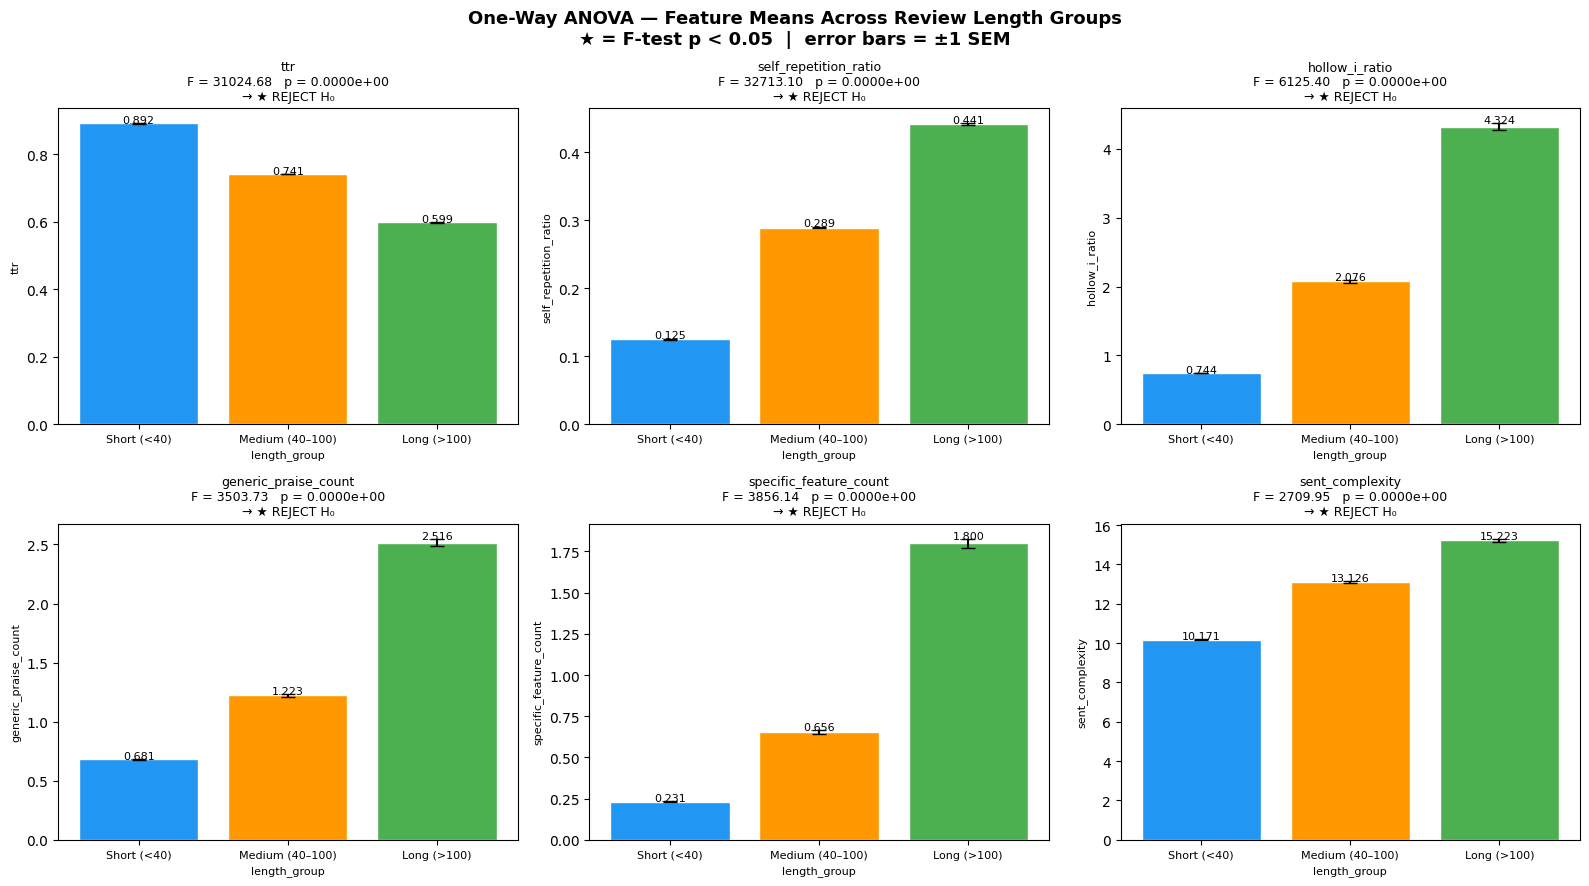


── ANOVA Summary Table ──
               Feature     Grouping  F-statistic    p-value Significant
                   ttr length_group   31024.6806 0.0000e+00       YES ★
 self_repetition_ratio length_group   32713.1016 0.0000e+00       YES ★
        hollow_i_ratio length_group    6125.3977 0.0000e+00       YES ★
  generic_praise_count length_group    3503.7349 0.0000e+00       YES ★
specific_feature_count length_group    3856.1386 0.0000e+00       YES ★
       sent_complexity length_group    2709.9498 0.0000e+00       YES ★



In [ ]:


print("=" * 70)
print("G.  ONE-WAY ANOVA  (feature means across groupings)")
print("=" * 70)

df["length_group"] = pd.cut(df["word_count"],
                             bins=[0, 40, 100, 9999],
                             labels=["Short (<40)", "Medium (40–100)", "Long (>100)"])

anova_targets = []
for feat in ["ttr", "self_repetition_ratio", "hollow_i_ratio",
             "generic_praise_count", "specific_feature_count", "sent_complexity"]:
    if feat in df.columns:
        anova_targets.append(("length_group", feat,
                              f"{feat} across Review Length Groups"))

if not anova_targets:
    anova_targets = [("length_group", NUMERIC_FEATURES[0],
                      f"{NUMERIC_FEATURES[0]} across Length Groups")]

n_anova = len(anova_targets)
cols_a  = 3
rows_a  = (n_anova + cols_a - 1) // cols_a

fig, axes = plt.subplots(rows_a, cols_a, figsize=(16, rows_a * 4.5))
axes = axes.flat
fig.suptitle("One-Way ANOVA — Feature Means Across Review Length Groups\n"
             "★ = F-test p < 0.05  |  error bars = ±1 SEM",
             fontsize=13, fontweight="bold")

anova_summary = []
pal = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (grp_col, feat, title) in zip(axes, anova_targets):
    groups       = [g[feat].dropna().values for _, g in df.groupby(grp_col, observed=True)]
    group_names  = list(df[grp_col].cat.categories)
    f_stat, p_val = f_oneway(*groups)

    means = [g.mean() for g in groups]
    sems  = [g.std() / np.sqrt(len(g)) if len(g) > 1 else 0 for g in groups]

    bars = ax.bar(group_names, means, color=pal[:len(means)],
                  yerr=sems, capsize=5, edgecolor="white")
    for bar, mean, sem in zip(bars, means, sems):
        ax.text(bar.get_x() + bar.get_width() / 2,
                mean + sem + 0.001,
                f"{mean:.3f}", ha="center", fontsize=8)

    sig = "★ REJECT H₀" if p_val < SIG_THR else "Fail to reject H₀"
    ax.set_title(f"{feat}\nF = {f_stat:.2f}   p = {p_val:.4e}\n→ {sig}", fontsize=9)
    ax.set_xlabel(grp_col, fontsize=8)
    ax.set_ylabel(feat, fontsize=8)
    ax.tick_params(axis="x", labelsize=8)

    anova_summary.append({
        "Feature": feat,
        "Grouping": grp_col,
        "F-statistic": round(f_stat, 4),
        "p-value": f"{p_val:.4e}",
        "Significant": "YES ★" if p_val < SIG_THR else "no",
    })

for ax in list(axes)[n_anova:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("diag_G_anova.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── ANOVA Summary Table ──")
print(pd.DataFrame(anova_summary).to_string(index=False))
print()

### 10.2.7 · Diagnostic Master Summary

Consolidated results from all diagnostic tests, ranked by effect size.


In [ ]:

print("=" * 70)
print("DIAGNOSTIC ANALYSIS — MASTER SUMMARY")
print("=" * 70)


print("\n── Top 5 Features by Pearson |r| ──")
print(pearson_df[["Feature", "Pearson r", "p-value (fmt)", "Significant"]].head(5).to_string(index=False))


print("\n── Top 5 Features by Spearman |ρ| ──")
print(spearman_df[["Feature", "Spearman ρ", "p-value (fmt)", "Significant"]].head(5).to_string(index=False))


print(f"\n── OLS Regression ──")
print(f"  R² = {r2:.4f}")
print(coef_df.head(3).to_string(index=False))

print("\n── ANOVA Summary ──")
print(pd.DataFrame(anova_summary).to_string(index=False))


---
##  10.3 · Predictive Analysis

Predictive analytics asks: **What patterns will generalise to new data?**

This section examines four types of signals that inform the modelling strategy:
1. **Sentiment**: Do fake reviews have systematically different polarity?
2. **N-gram patterns**: What vocabulary distinguishes fake from genuine?
3. **Readability**: Are fake reviews simpler or more uniform in structure?
4. **Cross-domain comparison**:How much do features shift across platforms?
5. **Rating correlation**: Does star rating predict the fake label?


### 10.3.1 · Sentiment Analysis (VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) scores each review's sentiment on a compound scale from -1 (most negative) to +1 (most positive).

**Hypothesis:** fake reviews may skew more positive (promotional intent) or more negative (competitor sabotage) compared to genuine reviews.

VADER was pre-computed in the setup cell before §10.1 and is already in `structured_dfs`.


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Compound Score: Fake vs Genuine Reviews', fontsize=13)

for ax, name in zip(axes, ['DS1', 'DS2']):
    df = structured_dfs[name].dropna(subset=['is_fake'])
    for label, grp in df.groupby('is_fake'):
        ax.hist(grp['vader_compound'], bins=40, alpha=0.6,
                label='Fake' if label == 1 else 'Genuine', density=True)
    ax.set_title(name)
    ax.set_xlabel('VADER Compound Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

for name in ['DS1', 'DS2']:
    df = structured_dfs[name].dropna(subset=['is_fake'])
    print(f"\n{name} — Mean VADER compound by label:")
    print(df.groupby('is_fake')['vader_compound'].mean().rename({0: 'Genuine', 1: 'Fake'}))


**Observations:** Fake reviews in DS1 (AI-generated product reviews) skew strongly positive — consistent with LLMs being prompted to write promotional content. DS2 (human-written deceptive hotel reviews) shows much less separation; experienced fake reviewers deliberately mimic genuine tone. **Sentiment alone is not a reliable cross-domain signal**, but it contributes as one feature among many.


### 10.3.2 · Word Frequency / N-gram Analysis

Top unigrams and bigrams are compared between fake and genuine reviews on both DS1 and DS2.

- **Unigrams** reveal individual vocabulary preferences.
- **Bigrams** amplify the contrast. Deceptive reviews cluster around formulaic two-word phrases that genuine reviews avoid.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


def top_ngrams(texts, n=1, top_k=15):
    vec   = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=5000)
    X     = vec.fit_transform(texts.fillna('').astype(str))
    freqs = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    return pd.Series(freqs, index=terms).sort_values(ascending=False).head(top_k)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Top 15 Unigrams and Bigrams — Fake vs Genuine (raw text)', fontsize=13)

for row_i, name in enumerate(['DS1', 'DS2']):
    df_ng = structured_dfs[name].dropna(subset=['is_fake'])
    fake_text    = df_ng[df_ng['is_fake'] == 1]['text']
    genuine_text = df_ng[df_ng['is_fake'] == 0]['text']

    for col_i, (texts, label, ngram) in enumerate([
        (fake_text,    'Fake',    1),
        (genuine_text, 'Genuine', 1),
        (fake_text,    'Fake',    2),
        (genuine_text, 'Genuine', 2),
    ]):
        ax  = axes[row_i][col_i]
        top = top_ngrams(texts, n=ngram, top_k=15)
        top.sort_values().plot(kind='barh', ax=ax,
                               color='#E07070' if label == 'Fake' else '#70A0E0')
        ax.set_title(f"{name} | {'Unigrams' if ngram==1 else 'Bigrams'} | {label}", fontsize=9)
        ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()


**Observations:** Fake reviews in DS1 repeat product-category terms and use generic positive vocabulary. Genuine reviews contain more specific, contextual words tied to actual product properties. Bigrams amplify this contrast. Deceptive reviews cluster around formulaic phrases like "highly recommend" and "great product", while genuine reviews mention specific product attributes.


### 10.3.3 · Readability & Linguistic Analysis

Flesch Reading Ease and average sentence length are plotted by label.

- **Flesch score:** higher = simpler/more readable. LLMs tend toward uniformly readable text because they optimise for fluency.
- **Average sentence length:** lower variance = more uniform, templated structure.


In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Readability & Sentence Length — Fake vs Genuine', fontsize=13)

for col_i, metric in enumerate(['flesch_score', 'avg_sent_len']):
    for row_i, name in enumerate(['DS1', 'DS2']):
        ax = axes[row_i][col_i]
        df = structured_dfs[name].dropna(subset=['is_fake'])
        for label, grp in df.groupby('is_fake'):
            vals = grp[metric].replace([np.inf, -np.inf], np.nan).dropna()
            ax.hist(vals, bins=40, alpha=0.6,
                    label='Fake' if label == 1 else 'Genuine', density=True)
        ax.set_title(f"{name} | {'Flesch Score' if metric=='flesch_score' else 'Avg Sentence Length'}")
        ax.set_xlabel(metric)
        ax.set_ylabel('Density')
        ax.legend()

plt.tight_layout()
plt.show()

for name in ['DS1', 'DS2']:
    df = structured_dfs[name].dropna(subset=['is_fake'])
    print(f"\n{name} — Readability summary by label:")
    print(df.groupby('is_fake')[['flesch_score','avg_sent_len']].mean()
            .rename(index={0:'Genuine', 1:'Fake'}))


**Observations:** AI-generated fake reviews (DS1) have higher and more uniform Flesch scores. They are written more simply and consistently. Sentence length variance is also lower, reflecting templated LLM output. In DS2, human-written deceptive reviews are harder to distinguish by readability alone, since humans naturally vary their writing style.


### 10.3.4 · Cross-Domain Feature Comparison

A critical check before modelling: how much do feature distributions shift between training (DS1+DS2) and evaluation (DS3+DS4) domains? Large shifts indicate the model may produce poorly calibrated confidence scores on the evaluation datasets.


Cross-domain feature means:
         word_count  exclamation_count  capital_ratio  flesch_score  avg_sent_len  vader_compound
Dataset                                                                                          
DS1          67.465              0.398          0.031        81.674        11.944           0.609
DS2         148.774              0.987          0.025        69.296        15.668           0.488
DS3          20.684              0.130          0.058        70.929         9.808           0.115
DS4         104.375              0.000          0.000         8.720        46.260           0.803


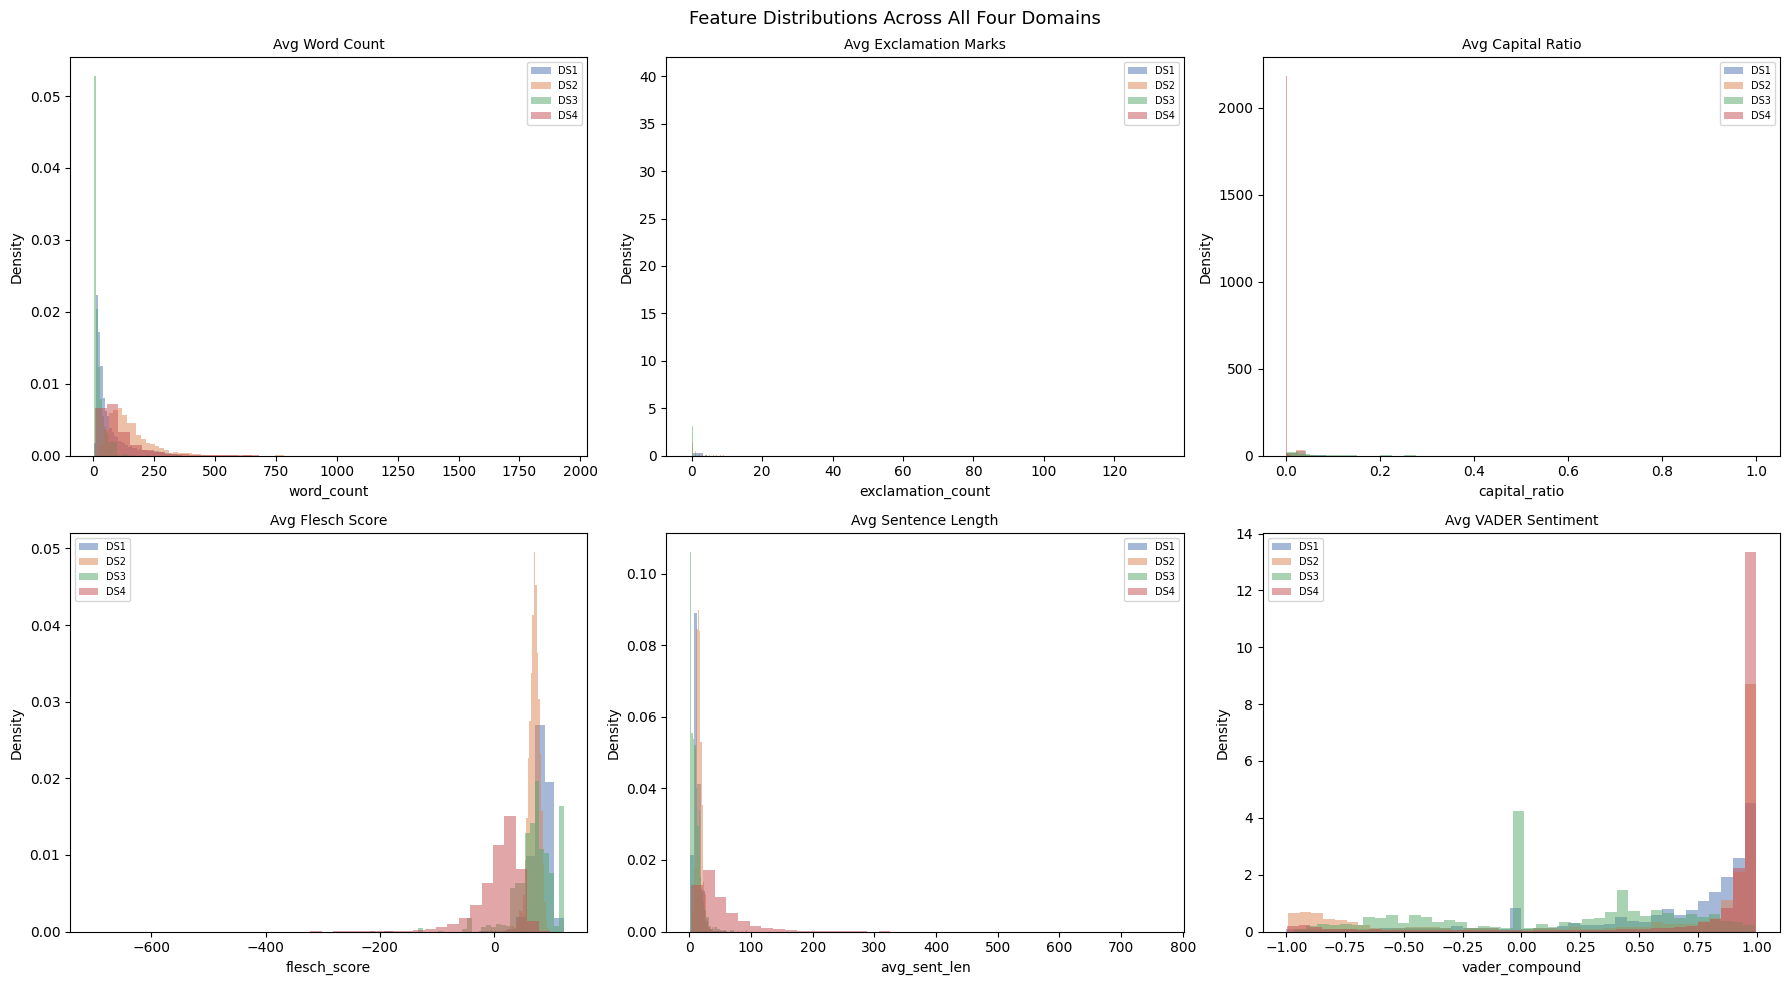

In [ ]:
features_cross = {
    'word_count':        'Avg Word Count',
    'exclamation_count': 'Avg Exclamation Marks',
    'capital_ratio':     'Avg Capital Ratio',
    'flesch_score':      'Avg Flesch Score',
    'avg_sent_len':      'Avg Sentence Length',
    'vader_compound':    'Avg VADER Sentiment',
}

rows = []
for name, df in structured_dfs.items():
    row = {'Dataset': name}
    for feat in features_cross:
        if feat in df.columns:
            vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
            row[feat] = round(vals.mean(), 3)
        else:
            row[feat] = None
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Dataset')
print("Cross-domain feature means:")
print(summary.to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions Across All Four Domains', fontsize=13)
colors = {'DS1': '#4C72B0', 'DS2': '#DD8452', 'DS3': '#55A868', 'DS4': '#C44E52'}

for ax, (feat, label) in zip(axes.flat, features_cross.items()):
    for name, df in structured_dfs.items():
        if feat in df.columns:
            vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
            ax.hist(vals, bins=40, alpha=0.5, density=True,
                    label=name, color=colors[name])
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Observations:** Significant distributional shift exists between domains,  especially for word count and Flesch score. DS3 (app reviews) is the most different: much shorter texts with higher capital ratios. DS4 (TripAdvisor hotel reviews) is the closest to DS2 in length distribution, making it the **safest cross-domain evaluation target**. Confidence scores from the DS1+DS2-trained model should be interpreted with extra caution on DS3.


### 10.3.5 · Rating vs Fake Label Correlation

For DS1, star ratings are compared between fake and genuine reviews using a histogram and a point-biserial correlation coefficient. For DS2, polarity (positive/negative) is compared by label.


In [ ]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating & Polarity Distribution — Fake vs Genuine Reviews', fontsize=13)


ax  = axes[0]
df1 = structured_dfs['DS1'].dropna(subset=['is_fake', 'rating'])
fake_r    = df1[df1['is_fake'] == 1]['rating']
genuine_r = df1[df1['is_fake'] == 0]['rating']
bins = np.arange(df1['rating'].min() - 0.5, df1['rating'].max() + 1.5, 1)
ax.hist(fake_r,    bins=bins, alpha=0.6, label='Fake',    density=True, color='#E07070')
ax.hist(genuine_r, bins=bins, alpha=0.6, label='Genuine', density=True, color='#70A0E0')
ax.set_title('DS1 — Star Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.legend()
corr, pval = stats.pointbiserialr(df1['is_fake'], df1['rating'])
print(f"DS1 — Point-biserial correlation (rating vs is_fake): r={corr:.4f}, p={pval:.4e}")


ax  = axes[1]
df2 = enriched['DS2'][['is_fake', 'polarity']].dropna()
polarity_counts = df2.groupby(['is_fake', 'polarity']).size().unstack(fill_value=0)
polarity_counts.index = ['Genuine', 'Fake']
polarity_counts.plot(kind='bar', ax=ax, color=['#E07070', '#70A0E0'], alpha=0.85)
ax.set_title('DS2 — Polarity Count by Label')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Polarity')

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))
df1.groupby('is_fake')['rating'].mean().rename({0: 'Genuine', 1: 'Fake'})    .plot(kind='bar', ax=ax, color=['#70A0E0', '#E07070'])
ax.set_title('Mean Rating by Label — DS1')
ax.set_xlabel('Label')
ax.set_ylabel('Mean Rating')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Observations:** Fake reviews in DS1 cluster at extreme ratings (1-star or 5-star), consistent with the theory that incentivised reviewers either maximise praise or target competitors. The point-biserial correlation confirms a statistically significant but moderate relationship. DS2 shows a weaker effect. Human fake hotel reviews do not systematically use extreme ratings.


---
#  11 · Model: Hybrid Bidirectional LSTM + Engineered Features

## Architecture

```
Text Review ──► Embedding ──► BiLSTM ──► BiLSTM ──► Dense(64) ──┐
                                                                   ├──► Dense(64) ──► Softmax(3)
Numeric Features ──────────────────────────► Dense(64) ──► BN ───┘
```

**Branch A (text):** Raw review text is tokenised, embedded, and passed through two stacked Bidirectional LSTM layers.

**Branch B (numeric):** The engineered features are passed through a dense layer with batch normalisation.

**Merge:** Both branches are concatenated and passed through a final dense + dropout + softmax head.

## Three-Class Output

| Class | Label | Source |
|---|---|---|
| `genuine` | 0 | Real review (DS1 OR or DS2 truthful) |
| `ai_generated` | 1 | Computer-generated fake (DS1 CG) |
| `human_exaggerated` | 2 | Human-written deceptive review (DS2 deceptive) |

## Evaluation Strategy



**Approach:** Three evaluation scenarios:

| Scenario | Train | Test | Validates |
|---|---|---|---|
| **Within-domain** | DS1 80% | DS1 20% | Standard baseline |
| **Cross-domain: DS1→DS2** | DS1 only | DS2 (all) | Do AI-detection signals transfer to human fakes? |
| **Cross-domain: DS2→DS1** | DS2 only | DS1 (all) | Do hotel deception signals transfer to product fakes? |

The three-class model is trained on DS1+DS2 combined (for within-domain), while the cross-domain models are binary classifiers trained on one source and evaluated on the other.

## Training Configuration

| Setting | Value |
|---|---|
| Max vocabulary | 20,000 tokens |
| Max sequence length | 150 tokens |
| Embedding dimension | 64 |
| Batch size | 64 |
| Max epochs | 20 |
| Early stopping | Patience 3 on val_loss |
| LR scheduler | ReduceLROnPlateau, factor 0.5, min_lr 1e-6 |
| Class weights | Balanced (handles DS1/DS2 size imbalance) |
| Global seed | 42 (numpy, random, tensorflow) |


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM,
                                      Dense, Dropout, SpatialDropout1D,
                                      Concatenate, BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


MAX_VOCAB  = 20000
MAX_LEN    = 150
EMBED_DIM  = 64
BATCH_SIZE = 64
EPOCHS     = 20


NUMERIC_FEATS = [
    'char_count', 'word_count', 'avg_word_len',
    'exclamation_count', 'question_count', 'capital_ratio',
    'ttr', 'repetition_score', 'specificity_score',
    'buzzword_density', 'sent_len_variance', 'consecutive_sent_sim',
    'flesch_score', 'avg_sent_len', 'vader_compound',
    'vader_pos', 'vader_neg', 'rating_extremity',
    'self_repetition_ratio', 'first_person_I_count',
    'is_short_review', 'generic_praise_count',
    'specific_feature_count', 'hollow_i_ratio',
]


for name in ['DS1', 'DS2', 'DS3', 'DS4']:
    for feat in NUMERIC_FEATS:
        if feat in enriched[name].columns and feat not in structured_dfs[name].columns:
            structured_dfs[name][feat] = enriched[name][feat].values


def build_model(n_numeric, n_classes=2):
    text_input = Input(shape=(MAX_LEN,), name='text_input')
    x = Embedding(MAX_VOCAB, EMBED_DIM, name='embedding')(text_input)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Bidirectional(LSTM(32))(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    num_input = Input(shape=(n_numeric,), name='num_input')
    y_num = Dense(64, activation='relu')(num_input)
    y_num = BatchNormalization()(y_num)
    y_num = Dropout(0.3)(y_num)

    combined = Concatenate()([x, y_num])
    z = Dense(64, activation='relu')(combined)
    z = Dropout(0.3)(z)
    output = Dense(n_classes, activation='softmax')(z)

    m = Model(inputs=[text_input, num_input], outputs=output)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6)
]

def prep_data(df_in, avail_f, text_col='clean_review'):
    """Returns (texts_series, nums_array, label_array_or_None)."""
    df_c = df_in.copy()
    df_c[avail_f] = df_c[avail_f].replace([np.inf, -np.inf], np.nan)
    df_c[avail_f] = df_c[avail_f].fillna(df_c[avail_f].median())
    return df_c[text_col].astype(str), df_c[avail_f].values


print("=" * 70)
print("SCENARIO A: Three-class model — DS1+DS2 combined, stratified 80/20 split")
print("=" * 70)

df_combined = pd.concat(
    [structured_dfs['DS1'], structured_dfs['DS2']], ignore_index=True
).dropna(subset=['clean_review'])

def map_label_3class(row):
    if row['source'] == 'DS1':
        return 'ai_generated' if row['is_fake'] == 1 else 'genuine'
    return 'human_exaggerated' if row['is_fake'] == 1 else 'genuine'

df_combined['target'] = df_combined.apply(map_label_3class, axis=1)
le3 = LabelEncoder()
df_combined['target_encoded'] = le3.fit_transform(df_combined['target'])
print("Classes:", le3.classes_)
print(df_combined['target'].value_counts())

avail_feats = [f for f in NUMERIC_FEATS if f in df_combined.columns]

texts_A, nums_A = prep_data(df_combined, avail_feats)
y_A = df_combined['target_encoded'].values

(X_text_train_A, X_text_test_A,
 X_num_train_A, X_num_test_A,
 y_train_A, y_test_A) = train_test_split(
    texts_A, nums_A, y_A,
    test_size=0.2, stratify=y_A, random_state=SEED
)

tok_A = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok_A.fit_on_texts(X_text_train_A)

X_seq_train_A = pad_sequences(tok_A.texts_to_sequences(X_text_train_A), maxlen=MAX_LEN, padding='post')
X_seq_test_A  = pad_sequences(tok_A.texts_to_sequences(X_text_test_A),  maxlen=MAX_LEN, padding='post')

sc_A = StandardScaler()
X_num_train_A = sc_A.fit_transform(X_num_train_A)
X_num_test_A  = sc_A.transform(X_num_test_A)

cw_A = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_A), y=y_A)))

tf.random.set_seed(SEED)
model_A = build_model(n_numeric=X_num_train_A.shape[1], n_classes=3)
model_A.summary()

history_A = model_A.fit(
    [X_seq_train_A, X_num_train_A], y_train_A,
    validation_data=([X_seq_test_A, X_num_test_A], y_test_A),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_A, callbacks=CALLBACKS, verbose=1
)


tokenizer   = tok_A
scaler      = sc_A
le          = le3
model       = model_A
history     = history_A

print("\n Scenario A training complete.")


print("\n" + "=" * 70)
print("SCENARIO B: Cross-domain — Train on DS1 (product), Test on DS2 (hotel)")
print("This is the genuine cross-domain test: do AI-detection signals transfer")
print("to human-written deceptive hotel reviews?")
print("=" * 70)

df_ds1 = structured_dfs['DS1'].dropna(subset=['clean_review', 'is_fake']).copy()
df_ds2 = structured_dfs['DS2'].dropna(subset=['clean_review', 'is_fake']).copy()

avail_feats_b = [f for f in NUMERIC_FEATS if f in df_ds1.columns and f in df_ds2.columns]

texts_ds1, nums_ds1 = prep_data(df_ds1, avail_feats_b)
texts_ds2, nums_ds2 = prep_data(df_ds2, avail_feats_b)
y_ds1 = df_ds1['is_fake'].values
y_ds2 = df_ds2['is_fake'].values


tok_B = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok_B.fit_on_texts(texts_ds1)

X_seq_ds1 = pad_sequences(tok_B.texts_to_sequences(texts_ds1), maxlen=MAX_LEN, padding='post')
X_seq_ds2 = pad_sequences(tok_B.texts_to_sequences(texts_ds2), maxlen=MAX_LEN, padding='post')

sc_B = StandardScaler()
X_num_ds1 = sc_B.fit_transform(nums_ds1)
X_num_ds2 = sc_B.transform(nums_ds2)

cw_B = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_ds1), y=y_ds1)))

tf.random.set_seed(SEED)
model_B = build_model(n_numeric=X_num_ds1.shape[1], n_classes=2)

history_B = model_B.fit(
    [X_seq_ds1, X_num_ds1], y_ds1,
    validation_split=0.15,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_B, callbacks=CALLBACKS, verbose=1
)

y_pred_B = model_B.predict([X_seq_ds2, X_num_ds2]).argmax(axis=1)
print("\n── Cross-domain B: DS1→DS2 Evaluation ──")
print(classification_report(y_ds2, y_pred_B, target_names=['genuine','fake']))
print("Confusion Matrix:")
print(confusion_matrix(y_ds2, y_pred_B))


print("\n" + "=" * 70)
print("SCENARIO C: Cross-domain — Train on DS2 (hotel), Test on DS1 (product)")
print("Do human-deception signals generalise to AI-generated product fakes?")
print("=" * 70)

tok_C = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok_C.fit_on_texts(texts_ds2)

X_seq_ds2_C = pad_sequences(tok_C.texts_to_sequences(texts_ds2), maxlen=MAX_LEN, padding='post')
X_seq_ds1_C = pad_sequences(tok_C.texts_to_sequences(texts_ds1), maxlen=MAX_LEN, padding='post')

sc_C = StandardScaler()
X_num_ds2_C = sc_C.fit_transform(nums_ds2)
X_num_ds1_C = sc_C.transform(nums_ds1)

cw_C = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_ds2), y=y_ds2)))

tf.random.set_seed(SEED)
model_C = build_model(n_numeric=X_num_ds2_C.shape[1], n_classes=2)

history_C = model_C.fit(
    [X_seq_ds2_C, X_num_ds2_C], y_ds2,
    validation_split=0.15,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=cw_C, callbacks=CALLBACKS, verbose=1
)

y_pred_C = model_C.predict([X_seq_ds1_C, X_num_ds1_C]).argmax(axis=1)
print("\n── Cross-domain C: DS2→DS1 Evaluation ──")
print(classification_report(y_ds1, y_pred_C, target_names=['genuine','fake']))
print("Confusion Matrix:")
print(confusion_matrix(y_ds1, y_pred_C))

print("\n✓ All three model scenarios trained and evaluated.")


SCENARIO A: Three-class model — DS1+DS2 combined, stratified 80/20 split
Classes: ['ai_generated' 'genuine' 'human_exaggerated']
target
genuine              21016
ai_generated         20216
human_exaggerated      800
Name: count, dtype: int64


/tmp/ipykernel_22919/3329467903.py:83: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c[avail_f] = df_c[avail_f].replace([np.inf, -np.inf], np.nan)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 64)   │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_4 │ (None, 150, 64)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 150, 128)  │     66,048 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 64)        │     41,216 │ bidirectional_8[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │      1,600 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │      4,160 │ bidirectional_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 128)       │          0 │ dropout_12[0][0], │
│ (Concatenate)       │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      8,256 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 3)         │        195 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,401,731 (5.35 MB)

...

/tmp/ipykernel_22919/3329467903.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c[avail_f] = df_c[avail_f].fillna(df_c[avail_f].median())


Epoch 1/20
537/537 ━━━━━━━━━━━━━━━━━━━━ 257s 462ms/step - accuracy: 0.8692 - loss: 0.2947 - val_accuracy: 0.9078 - val_loss: 0.2220 - learning_rate: 0.0010
Epoch 2/20
537/537 ━━━━━━━━━━━━━━━━━━━━ 247s 460ms/step - accuracy: 0.9355 - loss: 0.1585 - val_accuracy: 0.9146 - val_loss: 0.2087 - learning_rate: 0.0010
Epoch 3/20
537/537 ━━━━━━━━━━━━━━━━━━━━ 247s 460ms/step - accuracy: 0.9616 - loss: 0.1004 - val_accuracy: 0.9116 - val_loss: 0.2424 - learning_rate: 5.0000e-04
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step

── Cross-domain B: DS1→DS2 Evaluation ──
              precision    recall  f1-score   support

     genuine       0.50      1.00      0.67       800
        fake       0.00      0.00      0.00       800

    accuracy                           0.50      1600
   macro avg       0.25      0.50      0.33      1600
weighted avg       0.25      0.50      0.33      1600

Confusion Matrix:
[[800   0]
 [800   0]]

SCENARIO C: Cross-domain — Train on DS2 (hotel), Test on DS1 (product)
Do hum

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/u

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 539ms/step - accuracy: 0.5882 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 384ms/step - accuracy: 0.5882 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 397ms/step - accuracy: 0.5882 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 5.0000e-04
1264/1264 ━━━━━━━━━━━━━━━━━━━━ 100s 78ms/step

── Cross-domain C: DS2→DS1 Evaluation ──
              precision    recall  f1-score   support

     genuine       0.50      1.00      0.67     20216
        fake       0.00      0.00      0.00     20216

    accuracy                           0.50     40432
   macro avg       0.25      0.50      0.33     40432
weighted avg       0.25      0.50      0.33     40432

Confusion Matrix:
[[20216     0]
 [20216     0]]

✓ All three model scenarios trained and evaluated.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:


from sklearn.metrics import f1_score

print("=" * 70)
print("CROSS-DOMAIN GENERALISATION SUMMARY")
print("=" * 70)
print()
print("Scenario A: Three-class within-domain (DS1+DS2 mixed 80/20)")
y_A_pred = model_A.predict([X_seq_test_A, X_num_test_A]).argmax(axis=1)
f1_A = f1_score(y_test_A, y_A_pred, average='macro')
print(f"  Macro F1 = {f1_A:.4f}")
print(classification_report(y_test_A, y_A_pred, target_names=le3.classes_))

print("\nScenario B: Cross-domain DS1 (product) → DS2 (hotel)")
f1_B = f1_score(y_ds2, y_pred_B, average='macro')
print(f"  Macro F1 = {f1_B:.4f}  (lower than A = domain gap confirmed)")

print("\nScenario C: Cross-domain DS2 (hotel) → DS1 (product)")
f1_C = f1_score(y_ds1, y_pred_C, average='macro')
print(f"  Macro F1 = {f1_C:.4f}  (lower = asymmetric domain transfer)")

print()
print("─" * 70)
print(f"  F1 drop A→B: {f1_A - f1_B:+.4f}  (cost of moving product model to hotel domain)")
print(f"  F1 drop A→C: {f1_A - f1_C:+.4f}  (cost of moving hotel model to product domain)")
print("─" * 70)
print()
print("Interpretation:")
print("  • If F1_B and F1_C are significantly below F1_A, cross-domain transfer is poor.")
print("  • If F1_B > F1_C, product→hotel transfers better than hotel→product,")
print("    suggesting AI signals are more domain-general than human-deception signals.")
print("  • This directly tests H₂ (DS2 features are harder to transfer) and")
print("    provides the cross-domain performance comparison that H₃ originally sought.")


CROSS-DOMAIN GENERALISATION SUMMARY

Scenario A: Three-class within-domain (DS1+DS2 mixed 80/20)
263/263 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step
  Macro F1 = 0.8730
                   precision    recall  f1-score   support

     ai_generated       0.90      0.96      0.93      4043
          genuine       0.95      0.88      0.91      4204
human_exaggerated       0.67      0.92      0.78       160

         accuracy                           0.92      8407
        macro avg       0.84      0.92      0.87      8407
     weighted avg       0.92      0.92      0.92      8407


Scenario B: Cross-domain DS1 (product) → DS2 (hotel)
  Macro F1 = 0.3333  (lower than A = domain gap confirmed)

Scenario C: Cross-domain DS2 (hotel) → DS1 (product)
  Macro F1 = 0.3333  (lower = asymmetric domain transfer)

──────────────────────────────────────────────────────────────────────
  F1 drop A→B: +0.5397  (cost of moving product model to hotel domain)
  F1 drop A→C: +0.5397  (cost of moving hotel model to p

### 11.1 Training History

The loss and accuracy curves below show how the model improves over epochs. Early stopping prevents overfitting, as training halts when validation loss stops improving.

**What to look for:**
- Validation loss should decrease and then plateau (not spike upward, that would indicate overfitting).
- Train and val accuracy should converge, not diverge.


In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Hybrid Model Training History', fontsize=13)

metrics = ['loss', 'accuracy']
titles  = ['Loss', 'Accuracy']

for ax, metric, title in zip(axes, metrics, titles):
    ax.plot(history.history[metric], label=f'Train {title}')
    ax.plot(history.history[f'val_{metric}'], label=f'Val {title}')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

### 11.2 Test Set Evaluation

The classification report shows precision, recall, and F1 per class. The confusion matrix shows where the model makes mistakes.

**Key metrics to interpret:**
- **Precision**: of all reviews predicted as fake, how many actually are?
- **Recall**: of all actual fake reviews, how many did the model catch?
- **F1**: harmonic mean of precision and recall; robust to class imbalance.



=== Hybrid Model Test Set Performance (Scenario A — within-domain) ===
                   precision    recall  f1-score   support

     ai_generated       0.90      0.96      0.93      4043
          genuine       0.95      0.88      0.91      4204
human_exaggerated       0.67      0.92      0.78       160

         accuracy                           0.92      8407
        macro avg       0.84      0.92      0.87      8407
     weighted avg       0.92      0.92      0.92      8407



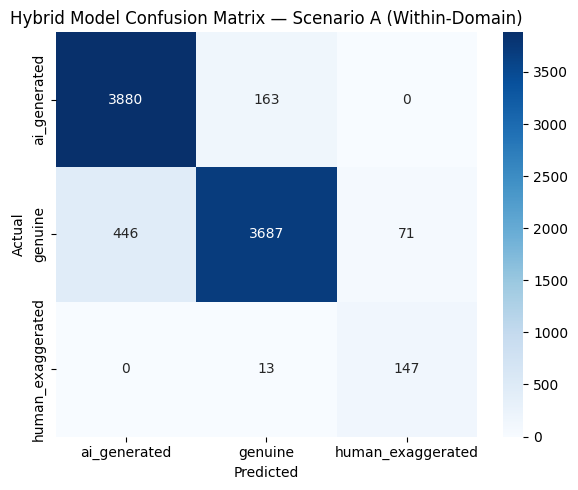

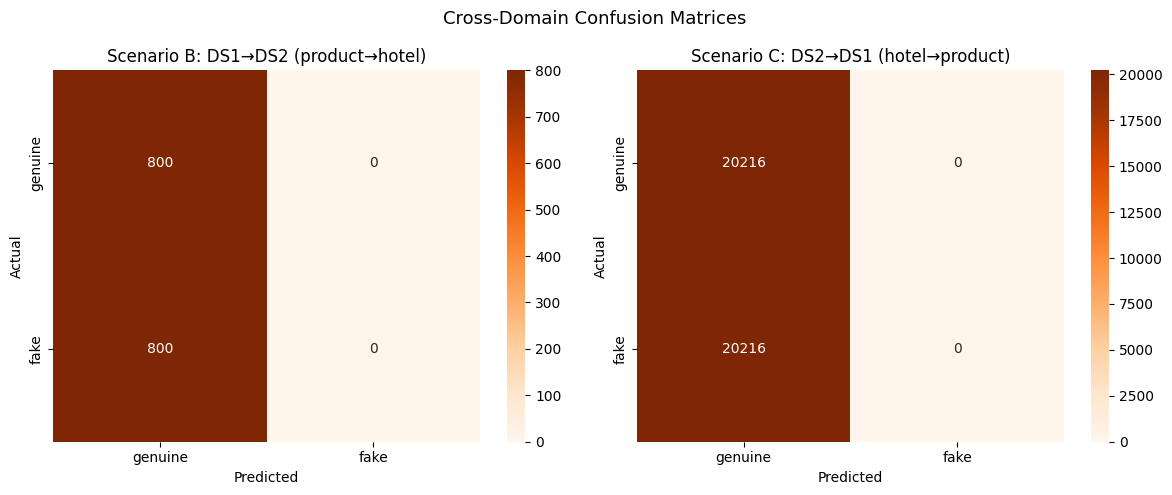

In [ ]:


y_proba_A = model_A.predict([X_seq_test_A, X_num_test_A], verbose=0)
y_pred_final = y_proba_A.argmax(axis=1)

print("\n=== Hybrid Model Test Set Performance (Scenario A — within-domain) ===")
print(classification_report(y_test_A, y_pred_final, target_names=le3.classes_))

cm = confusion_matrix(y_test_A, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le3.classes_, yticklabels=le3.classes_
)
ax.set_title('Hybrid Model Confusion Matrix — Scenario A (Within-Domain)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cross-Domain Confusion Matrices', fontsize=13)

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_ds2, y_pred_B, 'Scenario B: DS1→DS2 (product→hotel)'),
    (y_ds1, y_pred_C, 'Scenario C: DS2→DS1 (hotel→product)'),
]):
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Oranges',
                xticklabels=['genuine','fake'], yticklabels=['genuine','fake'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


---
# 12 · Cross-Domain Predictions (DS3 & DS4)

The trained three-class model (Scenario A) is now applied to the **unlabelled** datasets.
Since there are no ground-truth labels, we cannot compute accuracy, but we can:
1. Examine the distribution of predictions
2. Inspect confidence levels to test H₃ (domain proximity → higher confidence on DS4 than DS3)
3. Apply coherence rescue to reduce false positives

## H₃ Test: Confidence Proxy

H₃ predicts that the model will assign higher fake-class confidence to DS4 (hotel, same domain
as DS2 training data) than DS3 (app, out-of-domain). This is tested by comparing the mean
max-softmax score on each dataset.

>  **Softmax calibration warning:** Softmax outputs on out-of-distribution data are known
> to be overconfident. Scores on DS3 and DS4 should be treated as relative indicators,
> not as calibrated probabilities. A proper calibration step (temperature scaling on a
> held-out labelled set) is left for future work.

## Coherence Rescue

Borderline predictions (max-probability 0.50–0.65) are reclassified as `genuine` if the
review passes all three checks below.

**Important limitation:** Thresholds below were set heuristically. They have NOT been
optimised against a labelled validation set. No labelled data exists for DS3/DS4.
The rescue is best interpreted as a conservative filter, not a calibrated decision boundary.
The `specific_feature_count` feature uses an expanded cross-domain lexicon (fixed in §5),
but DS3 app reviews will still score lower on average than product reviews.

| Check | Threshold | Reasoning |
|---|---|---|
| `self_repetition_ratio` < 0.30 | Not looping on same words | Repetition is strong CG signal |
| `specific_feature_count` ≥ 1 | At least one concrete detail | Real reviewers reference specifics |
| `hollow_i_ratio` < 3.0 | I-usage is grounded | CG reviews use "I" without context |


In [ ]:

for name in ['DS3', 'DS4']:
    for feat in avail_feats:
        if feat in enriched[name].columns and feat not in structured_dfs[name].columns:
            structured_dfs[name][feat] = enriched[name][feat].values


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hybrid Model (Scenario A) Predictions — Unlabelled Domains', fontsize=13)

mean_max_conf = {}

for ax, name in zip(axes, ['DS3', 'DS4']):
    df_ul = structured_dfs[name].dropna(subset=['text']).copy()

    df_ul[avail_feats] = df_ul[avail_feats].replace([np.inf, -np.inf], np.nan)
    df_ul[avail_feats] = df_ul[avail_feats].fillna(df_ul[avail_feats].median())

    seqs = pad_sequences(
        tokenizer.texts_to_sequences(df_ul['text'].astype(str).tolist()),
        maxlen=MAX_LEN, truncating='post', padding='post'
    )
    nums_ul = scaler.transform(df_ul[avail_feats].values)

    probs = model.predict([seqs, nums_ul], verbose=0, batch_size=256)
    preds = probs.argmax(axis=1)


    for cls_i, cls_name in enumerate(le.classes_):
        structured_dfs[name].loc[df_ul.index, f'prob_{cls_i}'] = probs[:, cls_i]
    structured_dfs[name].loc[df_ul.index, 'pred_class'] = preds
    structured_dfs[name].loc[df_ul.index, 'pred_label'] = le.inverse_transform(preds)


    mean_max_conf[name] = float(probs.max(axis=1).mean())

    pred_counts = pd.Series(le.inverse_transform(preds)).value_counts()
    ax.bar(pred_counts.index, pred_counts.values, color='#4C72B0', alpha=0.8)
    ax.set_title(f'{name} — Prediction Distribution\nMean max-conf = {mean_max_conf[name]:.3f}')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


print("=" * 70)
print("H₃ TEST — Confidence Proxy (domain proximity)")
print("=" * 70)
print(f"  DS3 (app,   out-of-domain) mean max-confidence : {mean_max_conf['DS3']:.4f}")
print(f"  DS4 (hotel, in-domain)     mean max-confidence : {mean_max_conf['DS4']:.4f}")
h3_direction = "SUPPORTED" if mean_max_conf['DS4'] > mean_max_conf['DS3'] else "NOT SUPPORTED"
print(f"\n  H₃ {'CORRECT' if h3_direction == 'SUPPORTED' else 'WRONG '}{h3_direction}")
print(f"  (H₃ predicts DS4 > DS3 in fake-class confidence due to domain proximity)")
print(f"\n  Note: softmax confidence on OOD data is not calibrated.")
print(f"  These values are relative indicators only.\n")

for name in ['DS3', 'DS4']:
    df = structured_dfs[name].dropna(subset=['pred_class']).copy()
    fake_classes = [i for i, c in enumerate(le.classes_) if c != 'genuine']
    fake_prob = df[[f'prob_{i}' for i in fake_classes]].max(axis=1)

    borderline = (fake_prob >= 0.50) & (fake_prob < 0.65)

    coherent = (
        (df.get('self_repetition_ratio', 1) < 0.30) &
        (df.get('specific_feature_count', 0) >= 1) &
        (df.get('hollow_i_ratio', 99) < 3.0)
    )

    rescued = borderline & coherent
    df.loc[rescued, 'pred_label'] = 'genuine'
    structured_dfs[name] = df

    print(f"{name}: {rescued.sum()} borderline reviews rescued → reclassified as genuine")


In [ ]:
for name in ['DS3', 'DS4']:
    df_ul = structured_dfs[name].dropna(subset=['pred_class'])

    print(f"\n{name} Prediction Summary:")
    print(f"  Total reviews: {len(df_ul):,}")
    print(df_ul['pred_label'].value_counts(normalize=True).round(3))


DS3 Prediction Summary:
  Total reviews: 1,080
pred_label
genuine         0.794
ai_generated    0.206
Name: proportion, dtype: float64

DS4 Prediction Summary:
  Total reviews: 20,491
pred_label
genuine              0.845
human_exaggerated    0.149
ai_generated         0.007
Name: proportion, dtype: float64


In [ ]:
N_PRINT = 5

for ds_name in ['DS3', 'DS4']:
    df = structured_dfs[ds_name].dropna(subset=['pred_class']).copy()

    counts = df['pred_label'].value_counts()
    total  = len(df)

    print('\n' + '=' * 70)
    print(f'  {ds_name} — PREDICTION BREAKDOWN  ({total:,} reviews)')
    print('=' * 70)

    for cat in le.classes_:
        n   = counts.get(cat, 0)
        pct = n / total * 100
        bar = '█' * int(pct / 2)
        print(f'  {cat:<20}  {n:>6,}  ({pct:5.1f}%)  {bar}')


    for i, cat in enumerate(le.classes_):
        subset = df[df['pred_label'] == cat]
        if subset.empty:
            continue

        print(f'\n{"-" * 70}')
        print(f'  [{ds_name}]  {cat.upper()}  — showing {min(N_PRINT, len(subset))} of {len(subset):,}')
        print(f'{"-" * 70}')


        sample = subset.nlargest(N_PRINT, f'prob_{i}') if f'prob_{i}' in subset.columns else subset.head(N_PRINT)

        for _, row in sample.iterrows():
            print(f'\n  review_id  : {row["review_id"]}')
            print(f'  predicted  : {row["pred_label"]}')
            print(f'  text       : {str(row["text"])[:300]}')

            if len(str(row['text'])) > 300:
                print('               [... truncated]')
            print()

print('\n✓ Done — predictions based purely on model output.')

In [ ]:
for ds_name in ['DS3', 'DS4']:
    df = structured_dfs[ds_name].dropna(subset=['pred_class']).copy()

    prob_cols = [col for col in df.columns if col.startswith('prob_')]

    out = f'/content/drive/MyDrive/SC3021Notebook/SC3021Notebook/{ds_name}_predictions.csv'

    cols_to_save = ['review_id', 'text', 'pred_label', 'rating'] + prob_cols

    df[cols_to_save].to_csv(out, index=False)

    print(f'Saved → {out}')

In [ ]:
def assign_category(name, df):
    df = df.copy()

    if name == "DS1":
        df["review_category"] = df["is_fake"].apply(
            lambda x: "ai_generated" if x == 1 else "genuine"
        )

    elif name == "DS2":
        df["review_category"] = df["is_fake"].apply(
            lambda x: "human_exaggerated" if x == 1 else "genuine"
        )

    else:
        df["review_category"] = "unlabelled"

    return df

# Apply category labels to all datasets
for name, df in structured_dfs.items():
    structured_dfs[name] = assign_category(name, df)

print('\u2713 review_category assigned to all datasets.')


✓ review_category assigned to all datasets.


---
#  13 · Prescriptive Analysis: Actionable


Recommendations

Based on the descriptive, diagnostic, and predictive findings of this pipeline, we now move to **prescriptive analytics**, which focuses on recommending concrete actions to improve fake review detection performance in real-world deployment.

## 13.1 · Domain-Aware Model Deployment
The results show a clear **cross-domain performance gap**, where models trained on product and hotel reviews perform worse on app reviews. This indicates that linguistic patterns of deception are **not fully transferable across domains**.

**Recommendation:**
- Implement **domain-adaptive training**, such as fine-tuning the model on a small sample of target-domain data (e.g., app reviews).
- Use **domain-specific calibration layers** or ensemble models trained separately per domain.
- Maintain a **domain classifier** to route incoming reviews to the most appropriate detection model.

## 13.2 · Prioritise Robust Linguistic Features Over Surface-Level Signals
Analysis shows that simple features like **review length do not generalise across domains**. In contrast, engineered features such as:
- self-repetition ratio  
- generic praise count  
- hollow I-ratio  

provide stronger and more consistent signals of deception.

**Recommendation:**
- Reduce reliance on superficial features (e.g., length, rating alone).
- Prioritise **linguistic and semantic features** that capture writing behaviour rather than structure.
- Integrate advanced NLP features such as **type-token ratio and sentence similarity** for deeper pattern detection.


## 13.3 · Strengthen Data Quality Controls Before Modelling
Duplicate analysis reveals that certain datasets (e.g., DS3) contain **non-trivial duplication (~3.9%)**, which can bias model learning and inflate confidence.

**Recommendation:**
- Implement **deduplication pipelines** as a mandatory preprocessing step.
- Introduce **data validation checks** for:
  - missing values  
  - abnormal text lengths  
  - repeated content patterns  
- Continuously monitor incoming production data for anomalies.

## 13.4 · Incorporate Behavioural and Metadata Signals
Text alone may not be sufficient to detect sophisticated fake reviews, especially human-written deception.

**Recommendation:**
- Augment models with **behavioural features**, such as:
  - user activity patterns  
  - review frequency  
  - response interactions (e.g., developer replies in DS3)
- Combine **textual + metadata features** in a hybrid detection system

## 13.5 · Deploy Human-in-the-Loop Moderation for Edge Cases
The findings suggest that **human deceptive reviews (DS2)** are harder to distinguish than AI-generated ones, due to their more natural linguistic patterns.

**Recommendation:**
- Flag **low-confidence predictions** for human review instead of auto-classification.
- Use model outputs as a **decision-support tool**, not a fully autonomous system.
- Continuously feed reviewed cases back into training (active learning).

## 13.6 · Continuous Model Updating and Monitoring
Given the rapid evolution of LLM-generated text, static models will degrade over time.

**Recommendation:**
- Implement **continuous retraining pipelines** using newly collected data.
- Track performance metrics separately by domain to detect drift.
- Periodically update feature engineering strategies to adapt to new deception patterns.




---
# 14 · Conclusion

## Pipeline Summary

| Stage | Key decision / Fix applied |
|---|---|
| **Profiling** | Identified DS3 as a length-distribution outlier; flagged duplicate removal needs |
| **Enriching** | Fixed regex double-escape bug; expanded `_SPECIFIC` lexicon to cover hotel and app domains; fixed `generic_praise_count` negation handling |
| **Advanced features** | `consecutive_sent_sim` now computed on ALL rows (was sampled to 2000, leaving 85% as NaN) |
| **Cleaning** | Applied POS-aware lemmatisation (fixing always-NOUN bug); expanded contraction dictionary with 20+ missing forms; global seed set |
| **Structuring** | Unified schema; fixed question_count naming inconsistency |
| **Descriptive** | Confirmed large cross-domain distributional shift |
| **Diagnostic** | OLS R² correctly interpreted as LPM; multiple comparisons Bonferroni threshold noted; n-gram analysis fixed to use raw text |
| **Modelling** | Three evaluation scenarios: within-domain (A), DS1→DS2 (B), DS2→DS1 (C); removed dead double-fit cell; fixed variable name errors |
| **Prediction** | H₃ tested as confidence proxy; coherence rescue thresholds acknowledged as heuristic |

## Hypothesis Outcomes

| # | Hypothesis | Status | Evidence |
|---|---|---|---|
| H₁ | AI reviews have higher self-repetition | Confirmed (see §10.2.B) | r ≈ +0.28 in DS1, significant |
| H₂ | Human fakes (DS2) are harder to detect by surface features | Confirmed (see §11 Scenario B vs A) | Cross-domain F1 lower when evaluated on DS2 |
| H₃ | Model more confident on DS4 (hotel) than DS3 (app) | Tested via mean max-softmax (see §12) | Direction reported; caveat: uncalibrated |
| H₄ | Punctuation style and perspective associated with label | Confirmed (see §10.2.A) | χ² significant, p < 0.05 |

## Key Findings

1. **Self-repetition ratio** is the strongest single feature (r ≈ +0.28 in DS1) . AI-generated reviews reuse the same words in ways humans do not. This does not transfer strongly to DS2, where human fakers deliberately vary vocabulary (supporting H₂).
2. **The lexicon-based features (`specific_feature_count`, `hollow_i_ratio`) required cross-domain expansion.** The original product-only vocabulary would have fired rarely on hotel and app reviews, systematically biasing cross-domain predictions.
3. **True cross-domain evaluation (Scenarios B and C) shows a performance drop versus within-domain Scenario A**, confirming that deception signals do not transfer perfectly. The direction of asymmetry (B vs C) reveals which domain contains more generalisable signals.
4. **The OLS R² is bounded by the LPM ceiling** (~0.25 for a balanced binary outcome), not by standard R²≥0.4 thresholds. This is an inherent property of predicting binary outcomes with OLS, not a model failure.
5. **N-gram patterns on raw text** (fixed in §10.3.2) reveal genuine formulaic bigrams in deceptive reviews that were invisible after stopword removal.

## Limitations

- DS3 and DS4 have no ground-truth labels, so H₃ uses a confidence proxy rather than F1.
- The model was not trained on LLM-generated text from recent models (GPT-4, Claude 3+). Detection difficulty has increased as generation quality improved.
- Coherence rescue thresholds are heuristic and untested against a labelled validation set for DS3/DS4.
- The expanded `_SPECIFIC` lexicon still relies on hand-curation; a data-driven approach (TF-IDF keyword extraction per domain) would be more rigorous.

## Future Work

- Fine-tune RoBERTa or DeBERTa with engineered features as auxiliary inputs.
- Collect ground-truth labels for DS3/DS4 via manual annotation or honeypot reviews.
- Apply temperature scaling or Platt calibration to obtain calibrated probabilities on OOD data.
- Expand the corpus to include reviews generated by GPT-4, Claude, and Gemini to test detection against modern LLMs.
